In [1]:
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
import datetime as dt
import numpy as np
import sys
import os
import csv
import json
from lmfit import minimize, Parameters, report_fit, fit_report
import mplhep as hep
from cycler import cycler
import copy
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import chi2

#mplhep CMS style
hep.style.use(hep.style.ROOT) # For now ROOT defaults to CMS
plt.style.use(hep.style.ROOT)

In [2]:
#parameters for PbPb 2023 
betastar = 500. #betastar in mm
dorosarm = 21.595E3 #lever arm of doroses in mm
Qx = 64.31 #betatron tunes
Qy = 59.32
pmass = 0.938 #proton mass in GeV
rp = 1.5346910E-15 #classical proton radius in mm
#fill parameters
nbunches = {}
ncolliding = {}
nb1 = {}
nb2 = {}
energy = {}
cm = {}
capsigmaX = {}
capsigmaY = {}
year = {}
fillStartTime = {}
axisRanges = {}
superSeparation = {} #super separation scans
folderNames2D = {} # folder names of the 2D scans

In [3]:
### fill 9212 from PbPb 2023
nbunches['9212'] = 404
ncolliding['9212'] = 346
nb1['9212'] = 50.309E11 / 404 #protons per bunch in beam 1
nb2['9212'] = 50.647E11 / 404 #protons per bunch in beam 2
energy['9212'] = 2680 #energy
cm['9212'] = 5.36 #cm energy
capsigmaX['9212'] =  0.033 #in mm from PLT
capsigmaY['9212'] =  0.023 #in mm from PLT
year['9212'] = 2023
fillStartTime['9212'] = 1696112242
axisRanges['9212'] = [[10,290]]
superSeparation['9212'] = []
folderNames2D['9212'] = []

In [4]:
#### 9212 ####
fill = '9212'
cmstext = 'Preliminary'
#cmstext = ''
filltext = "Fill " + fill + " (" + str(year[fill]) + ", " + str(cm[fill]) + " TeV)"
planes = ['X','Y']
bpms = ['doros','arc']
measurements = ['dorosX1','dorosY1','dorosX2','dorosY2','arcX1','arcY1','arcX2','arcY2']

In [5]:
#plot helpers
colors = ['blue','green','red','cyan','magenta','yellow','black','gray','orange','purple','brown','pink','lime','olive','teal','navy','gold','salmon','indigo','plum','chocolate','coral','aqua','crimson','khaki','lavender','beige','mintcream','slategray','firebrick','crimson','forestgreen','seagreen','darkblue','darkgreen','darkred','darkorange','lightblue','lightgreen','darkgray','dimgray','skyblue','dodgerblue','steelblue','slateblue','royalblue','midnightblue','cadetblue','powderblue','lightsteelblue','lightseagreen','mediumseagreen','springgreen','mediumspringgreen','lawngreen','greenyellow','chartreuse','darkolivegreen','palegreen','khaki','darkkhaki','peachpuff','papayawhip','moccasin','mistyrose','lavender','lavenderblush','lemonchiffon','mintcream','aliceblue','bisque','blanchedalmond','cornsilk','wheat','tan','sienna','saddlebrown','burlywood','rosybrown','indianred','peru','tomato','lightgoldenrodyellow','darkslateblue','darkslategray','palevioletred','mediumvioletred']
markers = {"em" : 'v', "vdM" : 'o', "im" : '^', "im1" : '^', "im2" : '^', "off" : 's', "cls" : 'D', "vls1" : '>', "vls2" : '>', "vlsX1" : '>', "vlsX2" : '>', "vlsY1" : '>', "vlsY2" : '>', "diag X+Y" : 'd', "diag X-Y" : 'd', "2D" : 'P'}
plt.rcParams.update({'font.size': 22})
plt.rcParams['xtick.labelsize']=22
plt.rcParams['ytick.labelsize']=22
c = plt.get_cmap('tab10').colors
plt.rcParams['axes.prop_cycle'] = cycler(color=c)

In [6]:
#read the file with the nominal values
PATH = '/home/jesusavc/phd/LUM/od_analysis/lead/' #path to the folder with the two formatted files
data_array = {} #array with the scan data for each scan
setfile = PATH + "set_scans_" + fill + ".csv"
headerset = ['folder','scannr','subscan','axis','beam','typenr','step','timestart','timestop','reldisplacement','dispx','dispy','setX1','setX2','setY1','setY2']
f = open(setfile, 'r')
reader = csv.reader(f)
timeborders = []
scan = 0
for row in reader :
    if row[headerset.index('subscan')] == "Zero" : #before after scan head-on periods
        timeborders.append([float(row[headerset.index('timestart')]),float(row[headerset.index('timestop')])])
    else :
        for element in headerset :
            scanid = row[headerset.index('subscan')] + '_' + row[headerset.index('beam')] + '_' + row[headerset.index('axis')] + '_' + row[headerset.index('scannr')]
            if element == 'folder' or element == 'subscan' :
                data_array.setdefault(scanid,{}).setdefault(element,row[headerset.index(element)])       
            elif element == 'beam' or element == 'axis' or element == 'scannr' or element == 'typenr' :
                data_array.setdefault(scanid,{}).setdefault(element,int(row[headerset.index(element)]))
            else :
                data_array.setdefault(scanid,{}).setdefault(element,[]).append(float(row[headerset.index(element)]))

In [7]:
def stddev (inputlist) :
    if np.std(inputlist, ddof = 1) < 1e-5 : return 1e-5
    else : return np.std(inputlist, ddof = 1)

#read the bpm file
bpmfile = PATH + fill + ".csv"
headerbpm = ['timestamp','arcLX1','arcRX1','dorosX1','arcLY1','arcRY1','dorosY1','arcLX2','arcRX2','dorosX2','arcLY2','arcRY2','dorosY2']
f = open(bpmfile, 'r')
reader = csv.reader(f)
next(reader)
rows = list(reader)
scannr = 0
for scan in data_array :
    for i in range(0,len(data_array[scan]['timestart'])) :
        time = []
        dorosX1 = []
        dorosY1 = []
        dorosX2 = []
        dorosY2 = []
        arcX1 = []
        arcY1 = []
        arcX2 = []
        arcY2 = []
        for row in rows :
            if float(row[headerbpm.index('timestamp')]) > data_array[scan]['timestart'][i]-0.5 and float(row[headerbpm.index('timestamp')]) < data_array[scan]['timestop'][i]+0.5 : 
                time.append(float(row[headerbpm.index('timestamp')]))
                dorosX1.append(float(row[headerbpm.index('dorosX1')])/1000)
                dorosY1.append(float(row[headerbpm.index('dorosY1')])/1000)
                dorosX2.append(float(row[headerbpm.index('dorosX2')])/1000)
                dorosY2.append(float(row[headerbpm.index('dorosY2')])/1000)
                arcX1.append((float(row[headerbpm.index('arcLX1')]) + float(row[headerbpm.index('arcRX1')]))/2000 + data_array[scan]['setX1'][i])
                arcY1.append((float(row[headerbpm.index('arcLY1')]) + float(row[headerbpm.index('arcRY1')]))/2000 + data_array[scan]['setY1'][i])
                arcX2.append((float(row[headerbpm.index('arcLX2')]) + float(row[headerbpm.index('arcRX2')]))/2000 + data_array[scan]['setX2'][i])
                arcY2.append((float(row[headerbpm.index('arcLY2')]) + float(row[headerbpm.index('arcRY2')]))/2000 + data_array[scan]['setY2'][i])
        data_array[scan].setdefault('time',[]).append(np.average(time))
        data_array[scan].setdefault('dorosX1',[]).append(np.average(dorosX1))
        data_array[scan].setdefault('dorosY1',[]).append(np.average(dorosY1))
        data_array[scan].setdefault('dorosX2',[]).append(np.average(dorosX2))
        data_array[scan].setdefault('dorosY2',[]).append(np.average(dorosY2))
        data_array[scan].setdefault('arcX1',[]).append(np.average(arcX1))
        data_array[scan].setdefault('arcY1',[]).append(np.average(arcY1))
        data_array[scan].setdefault('arcX2',[]).append(np.average(arcX2))
        data_array[scan].setdefault('arcY2',[]).append(np.average(arcY2))
        #std dev of the measurements in the steps
        data_array[scan].setdefault('doroserrX1',[]).append(stddev(dorosX1))
        data_array[scan].setdefault('doroserrY1',[]).append(stddev(dorosY1))
        data_array[scan].setdefault('doroserrX2',[]).append(stddev(dorosX2))
        data_array[scan].setdefault('doroserrY2',[]).append(stddev(dorosY2))
        data_array[scan].setdefault('arcerrX1',[]).append(stddev(arcX1))
        data_array[scan].setdefault('arcerrY1',[]).append(stddev(arcY1))
        data_array[scan].setdefault('arcerrX2',[]).append(stddev(arcX2))
        data_array[scan].setdefault('arcerrY2',[]).append(stddev(arcY2))

In [8]:
#scan borders for linOD
scannr = 0
for scan in data_array :
    for i in range (0,2) :
        time = []
        dorosX1 = []
        dorosY1 = []
        dorosX2 = []
        dorosY2 = []
        arcX1 = []
        arcY1 = []
        arcX2 = []
        arcY2 = []
        for row in rows :
            if float(row[headerbpm.index('timestamp')]) > timeborders[2*scannr+i][0]-0.5 and float(row[headerbpm.index('timestamp')]) < timeborders[2*scannr+i][1]+0.5 : 
                time.append(float(row[headerbpm.index('timestamp')]))
                dorosX1.append(float(row[headerbpm.index('dorosX1')])/1000)
                dorosY1.append(float(row[headerbpm.index('dorosY1')])/1000)
                dorosX2.append(float(row[headerbpm.index('dorosX2')])/1000)
                dorosY2.append(float(row[headerbpm.index('dorosY2')])/1000)
                arcX1.append((float(row[headerbpm.index('arcLX1')]) + float(row[headerbpm.index('arcRX1')]))/2000)
                arcY1.append((float(row[headerbpm.index('arcLY1')]) + float(row[headerbpm.index('arcRY1')]))/2000)
                arcX2.append((float(row[headerbpm.index('arcLX2')]) + float(row[headerbpm.index('arcRX2')]))/2000)
                arcY2.append((float(row[headerbpm.index('arcLY2')]) + float(row[headerbpm.index('arcRY2')]))/2000)
        data_array[scan].setdefault('timeborder',[]).append(np.average(time))
        data_array[scan].setdefault('borderdorosX1',[]).append(np.average(dorosX1))
        data_array[scan].setdefault('borderdorosY1',[]).append(np.average(dorosY1))
        data_array[scan].setdefault('borderdorosX2',[]).append(np.average(dorosX2))
        data_array[scan].setdefault('borderdorosY2',[]).append(np.average(dorosY2))
        data_array[scan].setdefault('borderarcX1',[]).append(np.average(arcX1))
        data_array[scan].setdefault('borderarcY1',[]).append(np.average(arcY1))
        data_array[scan].setdefault('borderarcX2',[]).append(np.average(arcX2))
        data_array[scan].setdefault('borderarcY2',[]).append(np.average(arcY2))
    scannr += 1

In [9]:
#collect before and after scan head-on points
doroslinod = {"TimeWindows": [], "OrbitDrifts_X": [], "OrbitDrifts_Y": [], "scan_names": []}
arclinod = {"TimeWindows": [], "OrbitDrifts_X": [], "OrbitDrifts_Y": [], "scan_names": []}
for scan in data_array :
    if(data_array[scan]['axis']) == 0 : axis = ''
    else : axis =  planes[data_array[scan]['axis']-1]
    if data_array[scan]['typenr'] > 0 : doroslinod['scan_names'].append(data_array[scan]['subscan'] + str(data_array[scan]['typenr']) + '_' + axis)
    else : doroslinod['scan_names'].append(data_array[scan]['subscan'] + '_' + axis)
    doroslinod['TimeWindows'].append([data_array[scan]['timeborder'][0],data_array[scan]['timeborder'][1],data_array[scan]['timeborder'][1]])
    doroslinod['OrbitDrifts_X'].append([(data_array[scan]['borderdorosX1'][0]-data_array[scan]['borderdorosX2'][0])*1000,(data_array[scan]['borderdorosX1'][1]-data_array[scan]['borderdorosX2'][1])*1000,(data_array[scan]['borderdorosX1'][1]-data_array[scan]['borderdorosX2'][1])*1000])
    doroslinod['OrbitDrifts_Y'].append([(data_array[scan]['borderdorosY1'][0]-data_array[scan]['borderdorosY2'][0])*1000,(data_array[scan]['borderdorosY1'][1]-data_array[scan]['borderdorosY2'][1])*1000,(data_array[scan]['borderdorosY1'][1]-data_array[scan]['borderdorosY2'][1])*1000])
    arclinod['OrbitDrifts_X'].append([(data_array[scan]['borderarcX1'][0]-data_array[scan]['borderarcX2'][0])*1000,(data_array[scan]['borderarcX1'][1]-data_array[scan]['borderarcX2'][1])*1000,(data_array[scan]['borderarcX1'][1]-data_array[scan]['borderarcX2'][1])*1000])
    arclinod['OrbitDrifts_Y'].append([(data_array[scan]['borderarcY1'][0]-data_array[scan]['borderarcY2'][0])*1000,(data_array[scan]['borderarcY1'][1]-data_array[scan]['borderarcY2'][1])*1000,(data_array[scan]['borderarcY1'][1]-data_array[scan]['borderarcY2'][1])*1000])

arclinod['scan_names'] = doroslinod['scan_names']
arclinod['TimeWindows'] = doroslinod['TimeWindows']
#write the linOD factors into json files
os.makedirs(PATH + 'linod_files', exist_ok=True)
with open(PATH + 'linod_files/OrbitDrift_' + fill + 'DOROS.json', 'w') as f:
    json.dump(doroslinod, f, ensure_ascii=False, indent=4)
with open(PATH + 'linod_files/OrbitDrift_' + fill + 'arcBPM.json', 'w') as f:
    json.dump(arclinod, f, ensure_ascii=False, indent=4)

In [10]:
os.makedirs(PATH + 'figures_fill' + fill, exist_ok=True)

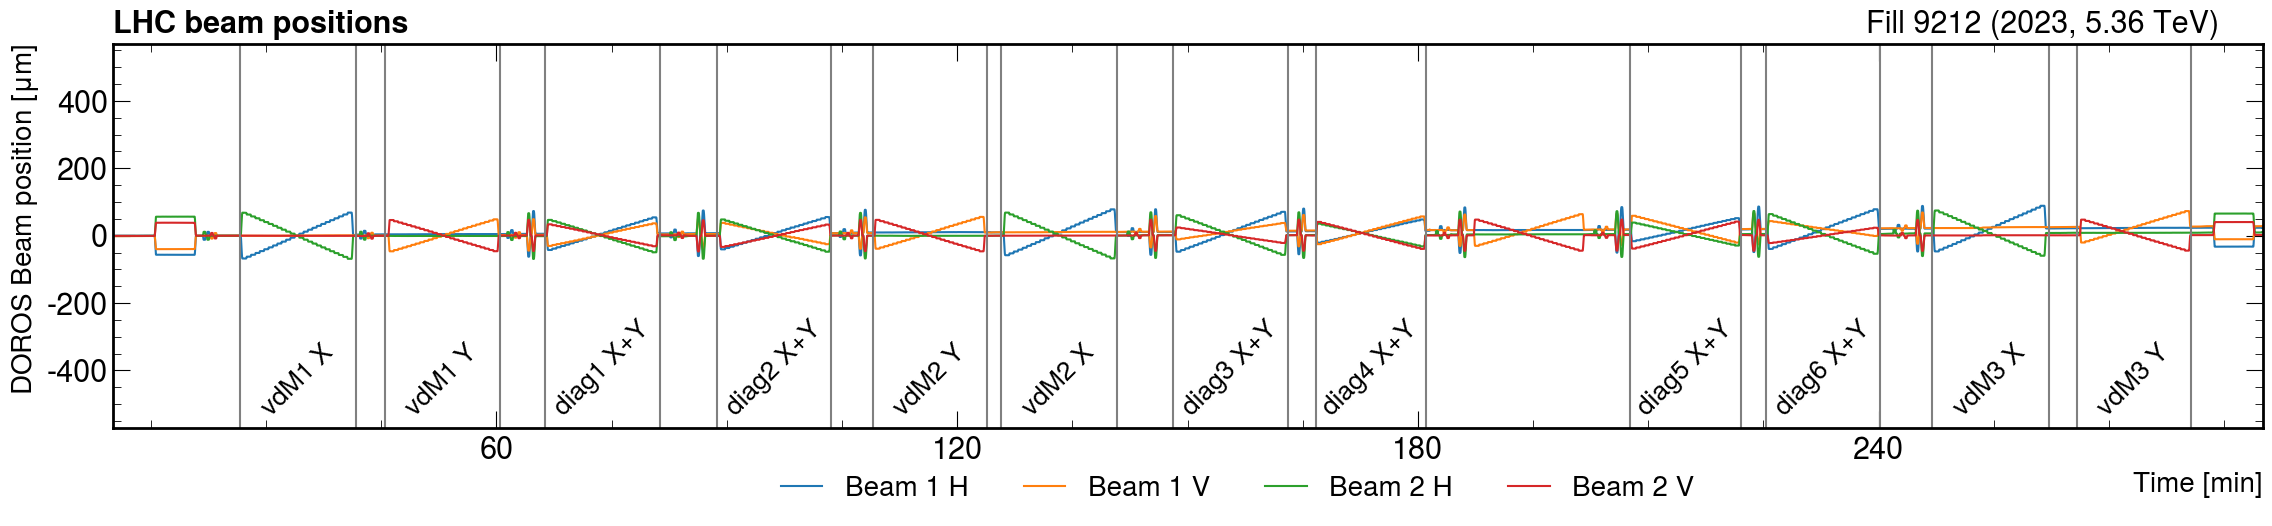

In [11]:
#plot doros bpm vs time
### read the scan names and borders ###
with open(PATH + 'linod_files/OrbitDrift_' + fill +'DOROS.json') as f:
    scans = json.load(f)

if len(superSeparation[fill]) > 0 :
    for i in range(0,int(len(superSeparation[fill])/2+1),2) :
        scans['TimeWindows'].append([superSeparation[fill][i],superSeparation[fill][i+1]])
        scans['scan_names'].append('ss' + str(int(i/2+1)))

time = []
X1 = []
Y1 = []
X2 = []
Y2 = []
for row in rows :
    time.append((float(row[headerbpm.index('timestamp')]) - fillStartTime[fill])/60)
    X1.append(float(row[headerbpm.index('dorosX1')]) - data_array[list(data_array)[0]]['borderdorosX1'][0]*1000)
    Y1.append(float(row[headerbpm.index('dorosY1')]) - data_array[list(data_array)[0]]['borderdorosY1'][0]*1000)
    X2.append(float(row[headerbpm.index('dorosX2')]) - data_array[list(data_array)[0]]['borderdorosX2'][0]*1000)
    Y2.append(float(row[headerbpm.index('dorosY2')]) - data_array[list(data_array)[0]]['borderdorosY2'][0]*1000)

sumTimeLength = 0.
for rang in axisRanges[fill] : sumTimeLength += rang[1] - rang[0]
ratios = []
for rang in axisRanges[fill] : ratios.append( (rang[1] - rang[0]) / sumTimeLength)
fig, ax = plt.subplots(1,len(ratios),figsize=(25,5),sharey=True, gridspec_kw={'width_ratios': ratios})
if type(ax) is matplotlib.axes._axes.Axes : ax = [ax]

plt.tight_layout()
ax[0].set_ylim([-570,570])

for i in range(0,len(ax)) :
    ax[i].plot(time, X1, label='Beam 1 H')
    ax[i].plot(time, Y1, label='Beam 1 V')
    ax[i].plot(time, X2, label='Beam 2 H')
    ax[i].plot(time, Y2, label='Beam 2 V')
    ax[i].set_xticks(np.arange(-0., axisRanges[fill][-1][1], step=60))    
    ax[i].set_xlim(axisRanges[fill][i][0],axisRanges[fill][i][1])
    ax[i].spines['left'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(axis='y',which='both',left=False,right=False,labelleft=False,labelright=False)

ax[0].spines['left'].set_visible(True)
ax[-1].spines['right'].set_visible(True)
ax[0].yaxis.tick_left()
ax[-1].yaxis.tick_right()
if len(ax) > 1 :
    ax[0].tick_params(axis='y',which='both',left=True,right=False,labelleft=True,labelright=False)
    ax[-1].tick_params(axis='y',which='both',left=False,right=True,labelleft=False,labelright=False)
else :
    ax[0].tick_params(axis='y',which='both',left=True,right=True,labelleft=True,labelright=False)

### lines on the axis at the breaking points ###
d = 2.  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
if(len(ax) > 1) :
    ax[0].plot([1, 1], [0, 1], transform=ax[0].transAxes, **kwargs)
    ax[-1].plot([0, 0], [0, 1], transform=ax[-1].transAxes, **kwargs)
if len(ax) > 2 : 
    for i in range(1,len(ax)-1) :
        ax[i].plot([0, 0], [0, 1], transform=ax[i].transAxes, **kwargs)
        ax[i].plot([1, 1], [0, 1], transform=ax[i].transAxes, **kwargs)
### tight layout ###        
plt.subplots_adjust(left=0.05, right=0.91, wspace=0.03, hspace=0.)

for i in range(0,len(scans['TimeWindows'])) : #scan names
    time = (scans['TimeWindows'][i][0]-fillStartTime[fill] + scans['TimeWindows'][i][1]-fillStartTime[fill])/ 2 / 60
    timestart = (scans['TimeWindows'][i][0] - fillStartTime[fill])/60
    timeend = (scans['TimeWindows'][i][1] - fillStartTime[fill])/60
    subscan = scans['scan_names'][i].replace("_"," ")
    for j in range(0,len(axisRanges[fill])) :
        if time > axisRanges[fill][j][0] and time < axisRanges[fill][j][1] : 
            ax[j].axvline(x = timestart, color = 'gray')
            ax[j].axvline(x = timeend, color = 'gray')
            if subscan.startswith('diag X+Y') :
                subscan = subscan.replace(' X+Y','')
                subscan += 'X+Y'
            if subscan.startswith('diag X-Y') :
                subscan = subscan.replace(' X-Y','')
                subscan += 'X-Y'
            if subscan.startswith('em1 X') == True or subscan.startswith('em2 X') == True or subscan.startswith('em3 X') == True or subscan.startswith('em4 X') == True or subscan.startswith('em5 X') == True :
                subscan = subscan.replace(" X","")
            if subscan.startswith('em1 Y') != True and subscan.startswith('em2 Y') != True and subscan.startswith('em3 Y') != True and subscan.startswith('em4 Y') != True and subscan.startswith('em5 Y') != True :
                #plt.text(time,-420+i%2*50, subscan, horizontalalignment='center', verticalalignment='bottom', transform=ax[j].transData, fontsize=16,rotation=45)
                plt.text(time,-550, subscan, horizontalalignment='center', verticalalignment='bottom', transform=ax[j].transData, fontsize=19,rotation=45)

ax[0].text(0., 1.01, "LHC beam positions",horizontalalignment='left',verticalalignment='bottom',transform=ax[0].transAxes,fontname='sans-serif',weight='bold',color="k",fontsize=22)
ax[-1].text(0.98, 1.01, filltext,horizontalalignment='right',verticalalignment='bottom',transform=ax[-1].transAxes,fontname='sans-serif',color="k",fontsize=22)
plt.xlabel("Time [min]", fontsize=20)
ax[0].set_ylabel("DOROS Beam position [$\mu m$]", fontsize=20)
ax[-1].legend(bbox_to_anchor=(0.5, 0.02), loc="center", prop={'size': 20}, ncol=4,bbox_transform=plt.gcf().transFigure)
plt.savefig(PATH + 'figures_fill' + fill + '/doros_vs_time_' + fill + '.pdf',bbox_inches='tight')
plt.savefig(PATH + 'figures_fill' + fill + '/doros_vs_time_' + fill + '.png',bbox_inches='tight')

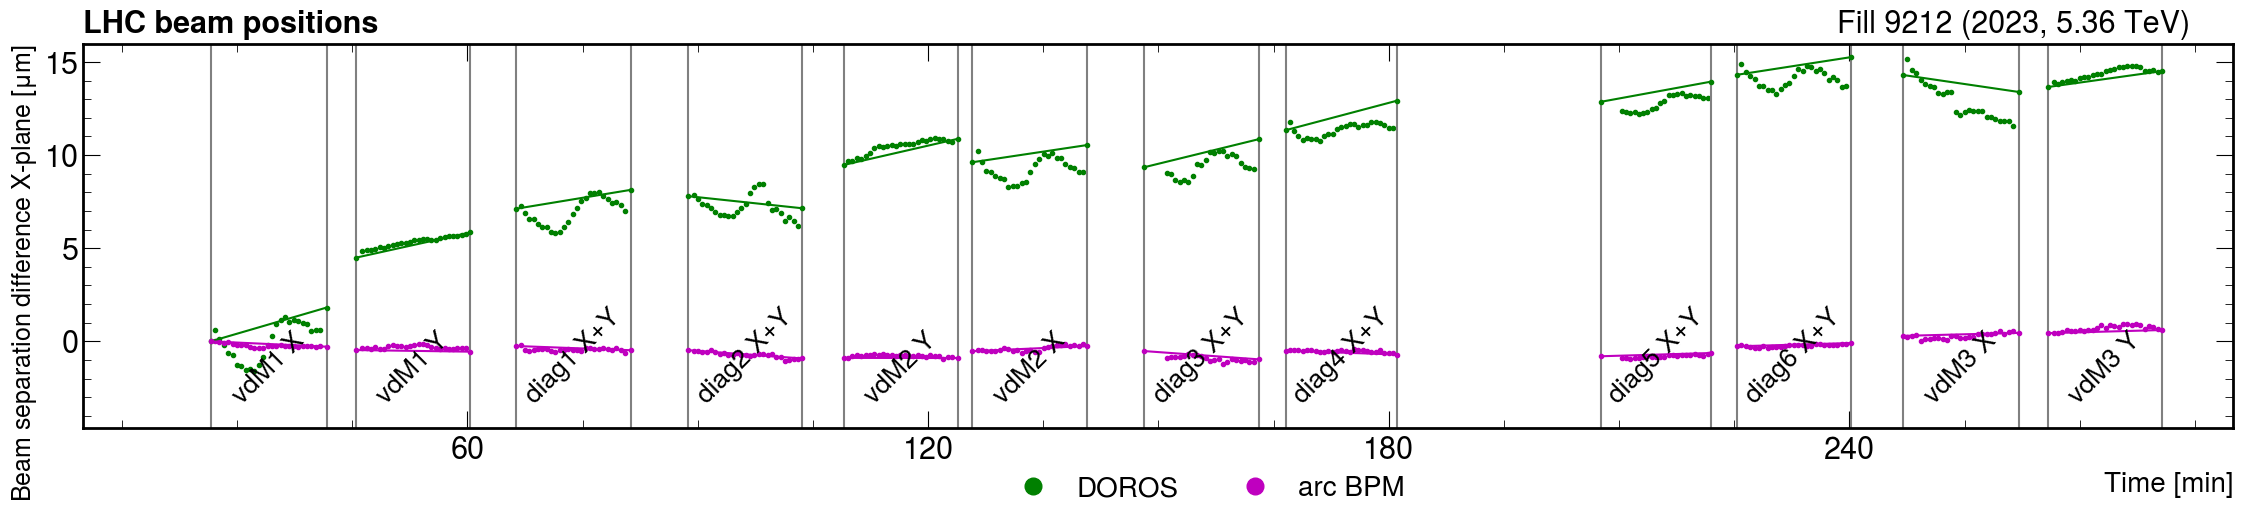

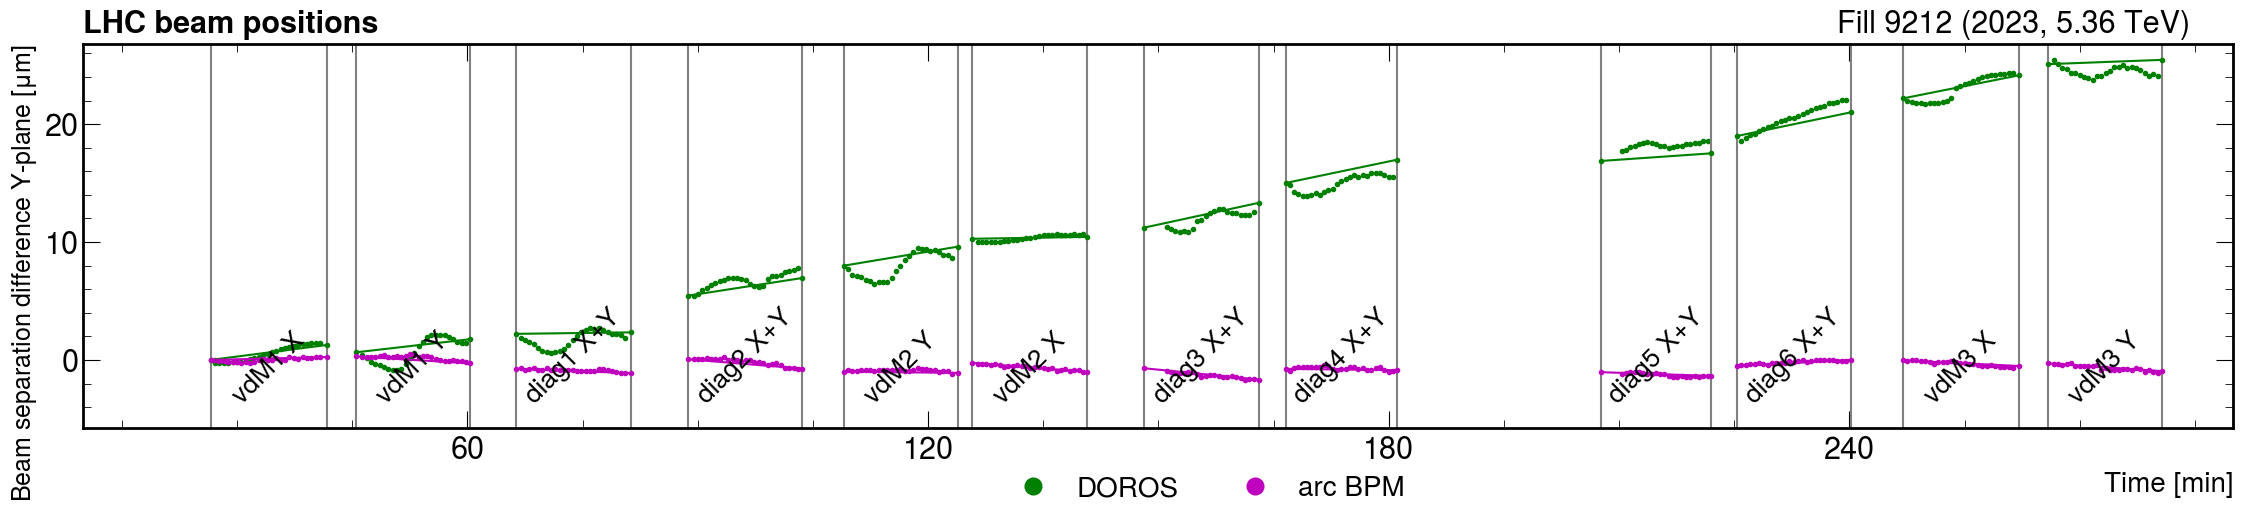

In [12]:
#OD vs time with linod interpolations
for plane in planes :
    time = []
    doros = []
    arc = []
    for scan in data_array :
        time.extend((np.array(data_array[scan]['time']) - fillStartTime[fill])/60)
        dorosdiff = np.array(data_array[scan]['doros' + plane + '1']) - np.array(data_array[scan]['doros' + plane + '2'])
        setdiff = np.array(data_array[scan]['set' + plane + '1']) - np.array(data_array[scan]['set' + plane + '2'])
        arcdiff = np.array(data_array[scan]['arc' + plane + '1']) - np.array(data_array[scan]['arc' + plane + '2'])
        doros.extend((dorosdiff-setdiff)*1000 - doroslinod['OrbitDrifts_' + plane][0][0])
        arc.extend((arcdiff-setdiff)*1000 - arclinod['OrbitDrifts_' + plane][0][0])

    sumTimeLength = 0.
    for rang in axisRanges[fill] : sumTimeLength += rang[1] - rang[0]
    ratios = []
    for rang in axisRanges[fill] : ratios.append( (rang[1] - rang[0]) / sumTimeLength)
    fig, ax = plt.subplots(1,len(ratios),figsize=(25,5),sharey=True, gridspec_kw={'width_ratios': ratios})
    if type(ax) is matplotlib.axes._axes.Axes : ax = [ax]
    plt.tight_layout()
    
    for i in range(0,len(ax)) :
        ax[i].plot(time, doros, ".", color='g', label="DOROS")
        #ax[i].plot(time, doros, ".", color='g', label="DOROS Left")
        
        ax[i].plot(time, arc, ".", color='m', label="arc BPM")
        ax[i].set_xticks(np.arange(-0., axisRanges[fill][-1][1], step=60))    
        ax[i].set_xlim(axisRanges[fill][i][0],axisRanges[fill][i][1])
        ax[i].spines['left'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(axis='y',which='both',left=False,right=False,labelleft=False,labelright=False)
    
    ax[0].spines['left'].set_visible(True)
    ax[-1].spines['right'].set_visible(True)
    ax[0].yaxis.tick_left()
    ax[-1].yaxis.tick_right()

    if len(ax) > 1 :
        ax[0].tick_params(axis='y',which='both',left=True,right=False,labelleft=True,labelright=False)
        ax[-1].tick_params(axis='y',which='both',left=False,right=True,labelleft=False,labelright=False)
    else :
        ax[0].tick_params(axis='y',which='both',left=True,right=True,labelleft=True,labelright=False)
    
    ### lines on the axis at the breaking points ###
    d = 2.  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                  linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    if len(ax) > 1 :
        ax[0].plot([1, 1], [0, 1], transform=ax[0].transAxes, **kwargs)
        ax[-1].plot([0, 0], [0, 1], transform=ax[-1].transAxes, **kwargs)
    if len(ax) > 2 : 
        for i in range(1,len(ax)-1) :
            ax[i].plot([0, 0], [0, 1], transform=ax[i].transAxes, **kwargs)
            ax[i].plot([1, 1], [0, 1], transform=ax[i].transAxes, **kwargs)
    ### tight layout ###        
    plt.subplots_adjust(left=0.05, right=0.91, wspace=0.03, hspace=0.)


    plt.ylim(ax[0].get_ylim()[0]*1.9)
    #plt.ylim(-50,30)
    yfraction = [ax[0].get_ylim()[0] + (abs(ax[0].get_ylim()[0]) + abs(ax[0].get_ylim()[1]))*0.05, ax[0].get_ylim()[0] + (abs(ax[0].get_ylim()[0]) + abs(ax[0].get_ylim()[1]))*0.1] #position of the scan names
    
    for i in range(0,len(scans['TimeWindows'])) : #scan names
        time = (scans['TimeWindows'][i][0]-fillStartTime[fill] + scans['TimeWindows'][i][1]-fillStartTime[fill])/ 2 / 60
        timestart = (scans['TimeWindows'][i][0] - fillStartTime[fill])/60
        timeend = (scans['TimeWindows'][i][1] - fillStartTime[fill])/60
        subscan = scans['scan_names'][i].replace("_"," ")
        for j in range(0,len(axisRanges[fill])) :
            if time > axisRanges[fill][j][0] and time < axisRanges[fill][j][1] :
                if subscan.startswith('ss'): continue
                ax[j].axvline(x = timestart, color = 'gray')
                ax[j].axvline(x = timeend, color = 'gray')
                if subscan.startswith('diag X+Y') :
                    subscan = subscan.replace(' X+Y','')
                    subscan += 'X+Y'
                if subscan.startswith('diag X-Y') :
                    subscan = subscan.replace(' X-Y','')
                    subscan += 'X-Y'
                if subscan.startswith('em1 X') == True or subscan.startswith('em2 X') == True or subscan.startswith('em3 X') == True or subscan.startswith('em4 X') == True or subscan.startswith('em5 X') == True :
                    subscan = subscan.replace(" X","")
                if subscan.startswith('em1 Y') != True and subscan.startswith('em2 Y') != True and subscan.startswith('em3 Y') != True and subscan.startswith('em4 Y') != True and subscan.startswith('em5 Y') != True :
                    #plt.text(time, yfraction[i%2], subscan, horizontalalignment='center', verticalalignment='center', transform=ax[j].transData, fontsize=18)
                    plt.text(time,yfraction[0], subscan, horizontalalignment='center', verticalalignment='bottom', transform=ax[j].transData, fontsize=19,rotation=45)

    for i in range(0,len(doroslinod['TimeWindows'])) : #linod representation
        time = [(doroslinod['TimeWindows'][i][0] - fillStartTime[fill])/60,(doroslinod['TimeWindows'][i][1] - fillStartTime[fill])/60]
        dorosborders = [doroslinod['OrbitDrifts_' + plane][i][0] - doroslinod['OrbitDrifts_' + plane][0][0],doroslinod['OrbitDrifts_' + plane][i][1] - doroslinod['OrbitDrifts_' + plane][0][0]]
        arcborders = [arclinod['OrbitDrifts_' + plane][i][0] - arclinod['OrbitDrifts_' + plane][0][0],arclinod['OrbitDrifts_' + plane][i][1] - arclinod['OrbitDrifts_' + plane][0][0]]       
        for j in range(0,len(axisRanges[fill])) :
            if time[0] > axisRanges[fill][j][0] and time[0] < axisRanges[fill][j][1] : 
                ax[j].plot(time, dorosborders, ".-", color='g')
                ax[j].plot(time, arcborders, ".-", color='m')

    ax[0].text(0., 1.01, "LHC beam positions",horizontalalignment='left',verticalalignment='bottom',transform=ax[0].transAxes,fontname='sans-serif',weight='bold',color="k",fontsize=22)
    ax[-1].text(0.98, 1.01, filltext,horizontalalignment='right',verticalalignment='bottom',transform=ax[-1].transAxes,fontname='sans-serif',color="k",fontsize=22)

    plt.xlabel("Time [min]", fontsize=20)
    ax[0].set_ylabel("Beam separation difference " + plane + "-plane [$\mu m$]", fontsize=18)
    #legend = ax[-1].legend(bbox_to_anchor=(1., 0.5), loc="center left", prop={'size': 24}, markerscale = 4.)
    ax[-1].legend(bbox_to_anchor=(0.5, 0.02), loc="center", prop={'size': 20}, markerscale = 4., ncol=2,bbox_transform=plt.gcf().transFigure)
    plt.savefig(PATH + 'figures_fill' + fill + '/od_vs_time_' + plane + '_' + fill + '.pdf',bbox_inches='tight')
    plt.savefig(PATH + 'figures_fill' + fill + '/od_vs_time_'+ plane + '_'  + fill + '.png',bbox_inches='tight')

In [13]:
#linOD correction
def linodcorrection(time, timelimit, bpm) :
    return bpm[0] + (((bpm[1] - bpm[0])/(timelimit[1] - timelimit[0]))*(time - timelimit[0]))

#keep the uncorrected values
data_array_nood = copy.deepcopy(data_array) 

for scan in data_array :
    for coord in measurements :
        for i in range(0,len(data_array[scan]['time'])) :
            data_array[scan][coord][i] -= linodcorrection(data_array[scan]['time'][i],data_array[scan]['timeborder'],data_array[scan]['border'+coord])

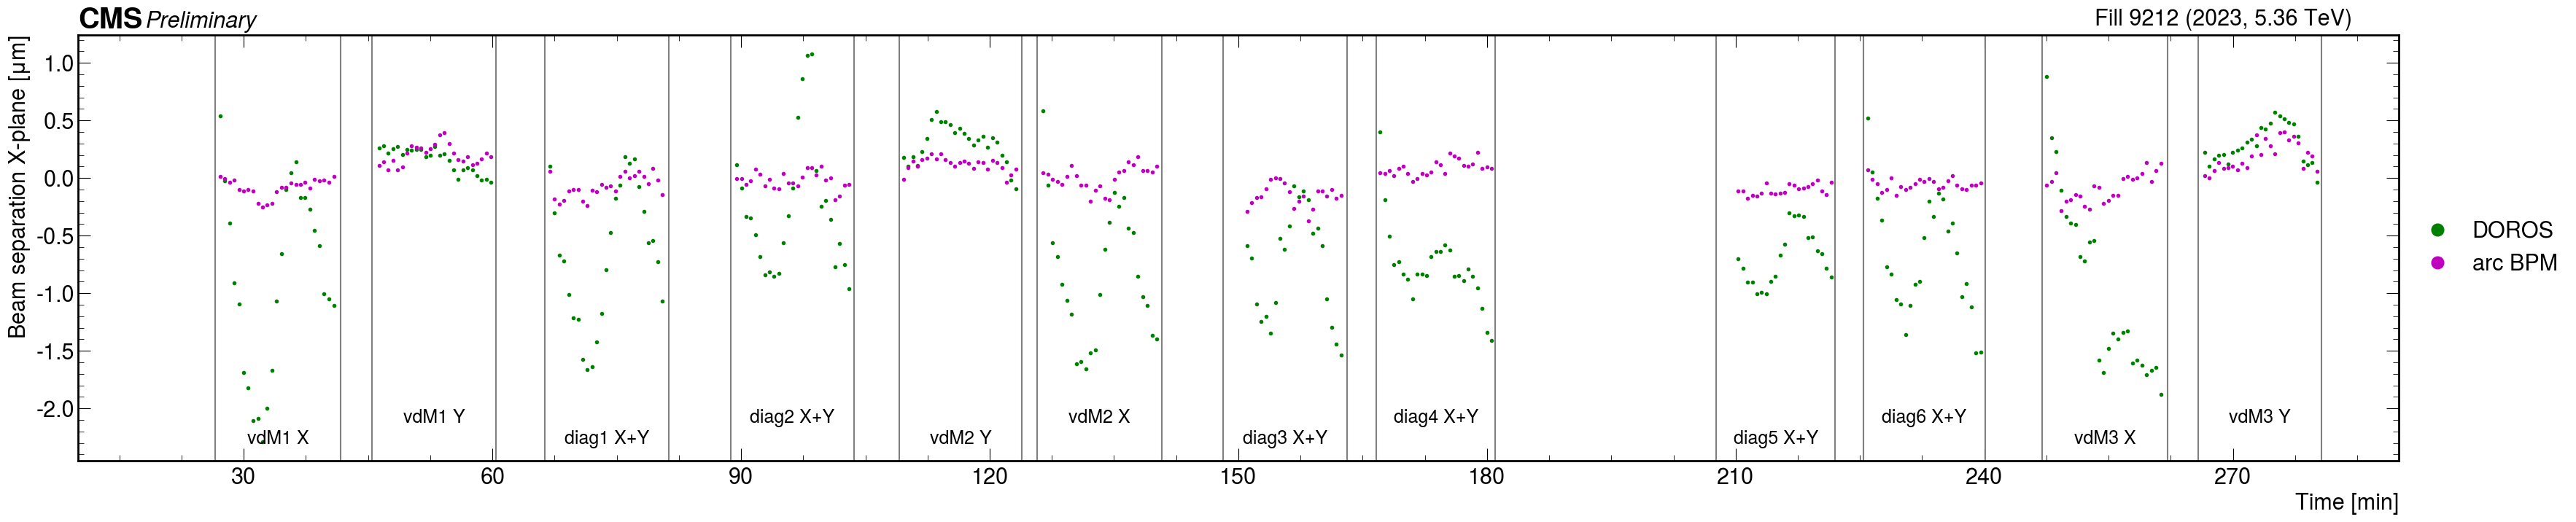

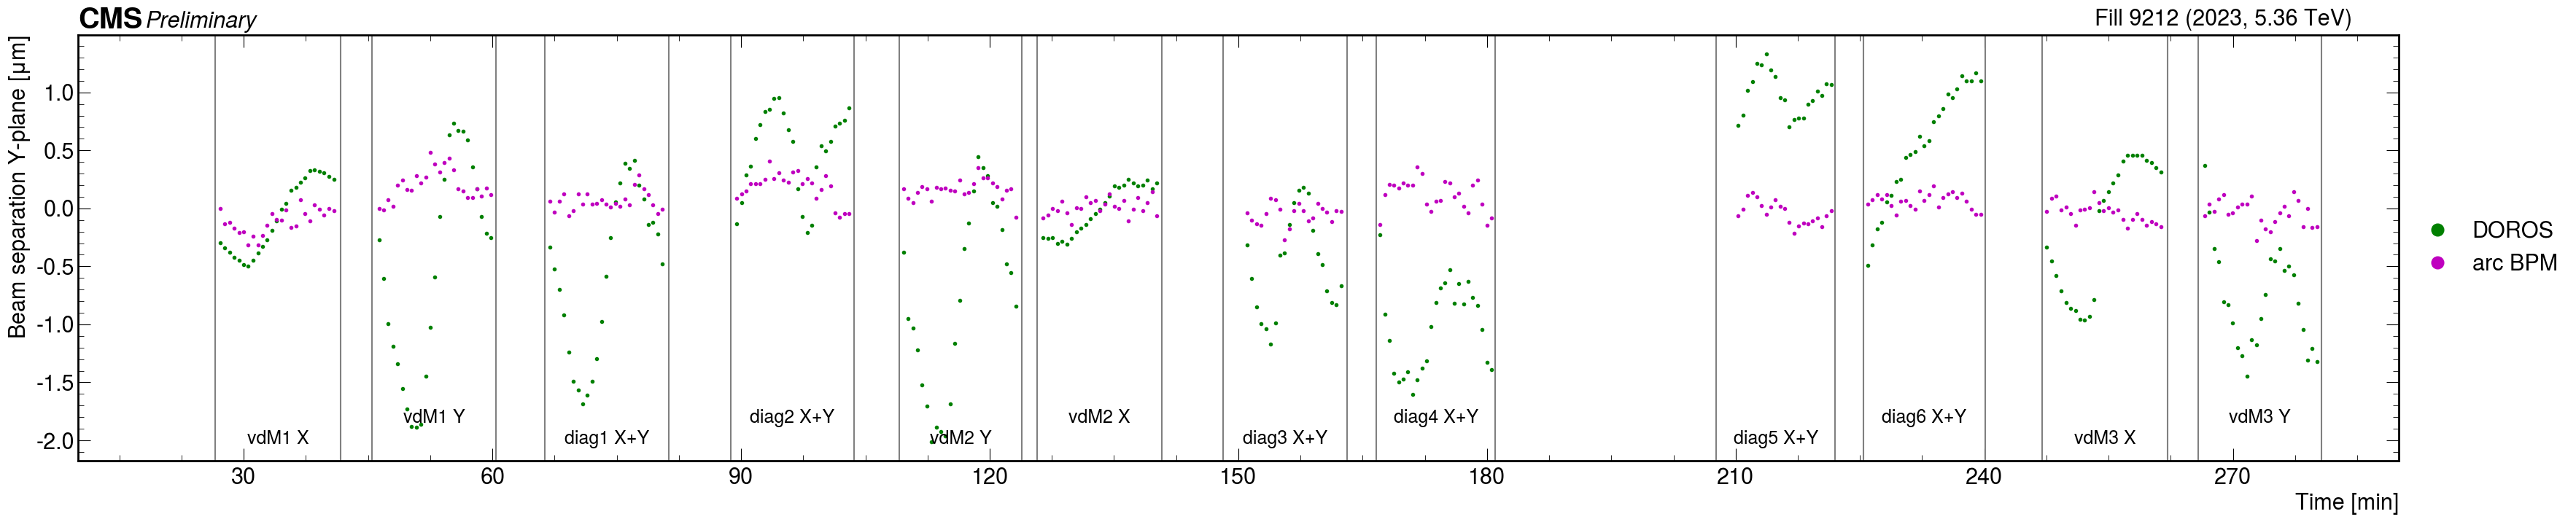

In [14]:
#OD vs time after linod correction
for plane in planes :
    time = []
    doros = []
    arc = []
    for scan in data_array :
        time.extend((np.array(data_array[scan]['time']) - fillStartTime[fill])/60)
        dorosdiff = np.array(data_array[scan]['doros' + plane + '1']) - np.array(data_array[scan]['doros' + plane + '2'])
        setdiff = np.array(data_array[scan]['set' + plane + '1']) - np.array(data_array[scan]['set' + plane + '2'])
        arcdiff = np.array(data_array[scan]['arc' + plane + '1']) - np.array(data_array[scan]['arc' + plane + '2'])
        doros.extend((dorosdiff-setdiff)*1000)
        arc.extend((arcdiff-setdiff)*1000)
       
    sumTimeLength = 0.
    for rang in axisRanges[fill] : sumTimeLength += rang[1] - rang[0]
    ratios = []
    for rang in axisRanges[fill] : ratios.append( (rang[1] - rang[0]) / sumTimeLength)
    fig, ax = plt.subplots(1,len(ratios),figsize=(37,7),sharey=True, gridspec_kw={'width_ratios': ratios})
    if type(ax) is matplotlib.axes._axes.Axes : ax = [ax]
    plt.tight_layout()
    
    for i in range(0,len(ax)) :
        ax[i].plot(time, doros, ".", color='g', label="DOROS")
        ax[i].plot(time, arc, ".", color='m', label="arc BPM")
        ax[i].set_xticks(np.arange(-0., axisRanges[fill][-1][1], step=30))    
        ax[i].set_xlim(axisRanges[fill][i][0],axisRanges[fill][i][1])
        ax[i].spines['left'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(axis='y',which='both',left=False,right=False,labelleft=False,labelright=False)
    
    ax[0].spines['left'].set_visible(True)
    ax[-1].spines['right'].set_visible(True)
    ax[0].yaxis.tick_left()
    ax[-1].yaxis.tick_right()

    if len(ax) > 1 :
        ax[0].tick_params(axis='y',which='both',left=True,right=False,labelleft=True,labelright=False)
        ax[-1].tick_params(axis='y',which='both',left=False,right=True,labelleft=False,labelright=False)
    else :
        ax[0].tick_params(axis='y',which='both',left=True,right=True,labelleft=True,labelright=False)
    
    ### lines on the axis at the breaking points ###
    d = 2.  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                  linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    if len(ax) > 1 :
        ax[0].plot([1, 1], [0, 1], transform=ax[0].transAxes, **kwargs)
        ax[-1].plot([0, 0], [0, 1], transform=ax[-1].transAxes, **kwargs)
    if len(ax) > 2 : 
        for i in range(1,len(ax)-1) :
            ax[i].plot([0, 0], [0, 1], transform=ax[i].transAxes, **kwargs)
            ax[i].plot([1, 1], [0, 1], transform=ax[i].transAxes, **kwargs)
    ### tight layout ###        
    plt.subplots_adjust(left=0.05, right=0.91, wspace=0.03, hspace=0.)


    yfraction = [ax[0].get_ylim()[0] + (abs(ax[0].get_ylim()[0]) + abs(ax[0].get_ylim()[1]))*0.05, ax[0].get_ylim()[0] + (abs(ax[0].get_ylim()[0]) + abs(ax[0].get_ylim()[1]))*0.1] #position of the scan names

    for i in range(0,len(scans['TimeWindows'])) : #scan names
        time = (scans['TimeWindows'][i][0]-fillStartTime[fill] + scans['TimeWindows'][i][1]-fillStartTime[fill])/ 2 / 60
        timestart = (scans['TimeWindows'][i][0] - fillStartTime[fill])/60
        timeend = (scans['TimeWindows'][i][1] - fillStartTime[fill])/60
        subscan = scans['scan_names'][i].replace("_"," ")
        for j in range(0,len(axisRanges[fill])) :
            if time > axisRanges[fill][j][0] and time < axisRanges[fill][j][1] : 
                ax[j].axvline(x = timestart, color = 'gray')
                ax[j].axvline(x = timeend, color = 'gray')
                if subscan.startswith('diag X+Y') :
                    subscan = subscan.replace(' X+Y','')
                    subscan += 'X+Y'
                if subscan.startswith('diag X-Y') :
                    subscan = subscan.replace(' X-Y','')
                    subscan += 'X-Y'
                if subscan.startswith('em1 X') == True or subscan.startswith('em2 X') == True or subscan.startswith('em3 X') == True or subscan.startswith('em4 X') == True or subscan.startswith('em5 X') == True :
                    subscan = subscan.replace(" X","")
                if subscan.startswith('em1 Y') != True and subscan.startswith('em2 Y') != True and subscan.startswith('em3 Y') != True and subscan.startswith('em4 Y') != True and subscan.startswith('em5 Y') != True :
                    plt.text(time, yfraction[i%2], subscan, horizontalalignment='center', verticalalignment='center', transform=ax[j].transData, fontsize=18)

    hep.cms.text(cmstext, loc=0, fontsize=22, ax=ax[0])
    ax[-1].text(0.98, 1.01, filltext,
                  horizontalalignment='right',
                  verticalalignment='bottom',
                  transform=ax[-1].transAxes,
                  fontname='sans-serif',
                  color="k",
                  fontsize=22)
    plt.xlabel("Time [min]", fontsize=22)
    ax[0].set_ylabel("Beam separation " + plane + "-plane [$\mu m$]", fontsize=22)
    ax[-1].legend(bbox_to_anchor=(1, 0.5), loc="center left", prop={'size': 22}, markerscale = 4.)
    plt.savefig(PATH + 'figures_fill' + fill + '/od_vs_time_linodcorrected_' + plane + '_' + fill + '.pdf')
    plt.savefig(PATH + 'figures_fill' + fill + '/od_vs_time_linodcorrected_'+ plane + '_'  + fill + '.png')

In [15]:
# AA beam-beam deflection. All positions and displacements here are in mm.
import numpy as np
from scipy.special import wofz


def gaussian_be_field(separation, capcov):
    """Bassetti-Erskine K=(Kx,Ky) in 1/mm for 2D Gaussian capcov [mm^2]."""
    d = np.asarray(separation, dtype=float)
    eig, rotation = np.linalg.eigh(np.asarray(capcov, dtype=float))
    if eig[0] <= 0:
        raise ValueError('Convolved covariance must be positive definite')
    eig = eig[::-1]
    rotation = rotation[:, ::-1]
    u, v = rotation.T @ d
    sx, sy = np.sqrt(eig)
    r2 = u*u + v*v
    if r2 == 0:
        return np.zeros(2)
    if abs(sx-sy)/sx < 1e-6:
        field = -np.expm1(-r2/(2*sx*sx))/r2 * np.array([u, v])
    elif r2 < 1e-10 * sy*sy:
        field = np.array([u/sx, v/sy])/(sx+sy)
    else:
        a, b = abs(u), abs(v)
        scale = np.sqrt(2*(sx*sx-sy*sy))
        exponent = -a*a/(2*sx*sx) - b*b/(2*sy*sy)
        w = -1j*np.sqrt(np.pi)/scale * (
            wofz((a+1j*b)/scale) - np.exp(exponent)*
            wofz((a*sy/sx+1j*b*sx/sy)/scale))
        field = np.array([np.sign(u)*w.real, -np.sign(v)*w.imag])
    return rotation @ field


def ion_bb_displacements(separation, N1_ions, N2_ions, Z, A, gamma, capcov,
                         beta_star, tunes, doros_arm, proton_radius):
    """Return [B1,B2] x [X,Y] displacements in mm for IP and DOROS."""
    K = gaussian_be_field(separation, capcov)
    # d = set(B1) - set(B2). Repulsion moves beam 1 along +K and
    # beam 2 along -K in the notebook's position coordinates.
    theta1 = +2*N2_ions*(Z*Z/A)*proton_radius/gamma * K
    theta2 = -2*N1_ions*(Z*Z/A)*proton_radius/gamma * K
    arc_factor = beta_star/(2*np.tan(np.pi*np.asarray(tunes)))
    doros_factor = arc_factor + doros_arm/2
    angles = np.stack([theta1, theta2])
    return angles*arc_factor, angles*doros_factor


# Fill 9212, Pb-208. Bunch intensities nb1/nb2 above are CHARGES per bunch.
# Covariances below are the individual beam covariances in um^2 from the
# PbPb reference; replace these with per-BCID measured matrices when available.
ion_by_fill = {
    '9212': {
        'Z': 82,
        'A': 207.97665,
        'cov1_um2': np.diag([515.205, 327.68]),
        'cov2_um2': np.diag([515.205, 327.68]),
    },
}
ions = ion_by_fill[fill]
Z, A = ions['Z'], ions['A']
N1_ions, N2_ions = nb1[fill]/Z, nb2[fill]/Z
# Convolution of the two transverse bunch profiles, in mm^2.
capcov = (ions['cov1_um2'] + ions['cov2_um2']) * 1e-6
gamma_ion = energy[fill]/pmass  # energy[fill] is GeV per nucleon

for scan, entry in data_array.items():
    separation = np.column_stack((
        np.asarray(entry['setX1']) - np.asarray(entry['setX2']),
        np.asarray(entry['setY1']) - np.asarray(entry['setY2']),
    ))
    for bpm in ('arc', 'doros'):
        for plane in ('X', 'Y'):
            for beam in (1, 2):
                for suffix in ('', 'mod'):
                    entry[f'bbshift{bpm}{plane}{beam}{suffix}'] = []

    for d in separation:
        arc, doros = ion_bb_displacements(
            d, N1_ions, N2_ions, Z, A, gamma_ion, capcov,
            betastar, (Qx, Qy), dorosarm, rp,
        )
        # Retain the notebook's historical simultaneous +10% intensity and
        # transverse-size variation as a control curve (not an uncertainty).
        arc_mod, doros_mod = ion_bb_displacements(
            d, 1.1*N1_ions, 1.1*N2_ions, Z, A, gamma_ion,
            (1.1**2)*capcov, betastar, (Qx, Qy), dorosarm, rp,
        )
        for bpm, nominal, varied in (
            ('arc', arc, arc_mod), ('doros', doros, doros_mod)
        ):
            for p, plane in enumerate(('X', 'Y')):
                for b, beam in enumerate((1, 2)):
                    key = f'bbshift{bpm}{plane}{beam}'
                    entry[key].append(float(nominal[b, p]))
                    entry[key + 'mod'].append(float(varied[b, p]))


In [16]:
# Step 1: Check if data_array exists and what type it is
print("=" * 50)
print("DEBUGGING DATA_ARRAY")
print("=" * 50)

print(f"\n1. Type of data_array: {type(data_array)}")
print(f"2. Length/size of data_array: {len(data_array)}")

DEBUGGING DATA_ARRAY

1. Type of data_array: <class 'dict'>
2. Length/size of data_array: 12


In [17]:
# Step 2: Check all keys in data_array
print(f"\n3. All keys in data_array:")
all_keys = list(data_array.keys())
print(f"   Total number of keys: {len(all_keys)}")
for i, key in enumerate(all_keys):
    print(f"   [{i}] {key}")


3. All keys in data_array:
   Total number of keys: 12
   [0] vdM_0_1_1
   [1] vdM_0_2_1
   [2] diag X+Y_0_0_2
   [3] diag X+Y_0_0_3
   [4] vdM_0_2_4
   [5] vdM_0_1_4
   [6] diag X+Y_0_0_5
   [7] diag X+Y_0_0_6
   [8] diag X+Y_0_0_7
   [9] diag X+Y_0_0_8
   [10] vdM_0_1_9
   [11] vdM_0_2_9


In [18]:
# Check the shapes of all the arrays
vdmscan = list(filter(lambda x: x.startswith('vdM'), list(data_array.keys())))

print(f"First VdM scan: {vdmscan[0]}")
print(f"Available keys: {list(data_array[vdmscan[0]].keys())}")
print()

# Check shapes
setX1 = np.array(data_array[vdmscan[0]]['setX1'])
setX2 = np.array(data_array[vdmscan[0]]['setX2'])
bbshiftarcX1 = np.array(data_array[vdmscan[0]]['bbshiftarcX1'])
bbshiftdorosX1 = np.array(data_array[vdmscan[0]]['bbshiftdorosX1'])

print(f"setX1 shape: {setX1.shape}")
print(f"setX2 shape: {setX2.shape}")
print(f"bbshiftarcX1 shape: {bbshiftarcX1.shape}")
print(f"bbshiftdorosX1 shape: {bbshiftdorosX1.shape}")
print()

x_data = setX1 - setX2
print(f"x_data (setX1 - setX2) shape: {x_data.shape}")
print(f"y_data (bbshiftarcX1) shape: {bbshiftarcX1.shape}")

First VdM scan: vdM_0_1_1
Available keys: ['folder', 'scannr', 'subscan', 'axis', 'beam', 'typenr', 'step', 'timestart', 'timestop', 'reldisplacement', 'dispx', 'dispy', 'setX1', 'setX2', 'setY1', 'setY2', 'time', 'dorosX1', 'dorosY1', 'dorosX2', 'dorosY2', 'arcX1', 'arcY1', 'arcX2', 'arcY2', 'doroserrX1', 'doroserrY1', 'doroserrX2', 'doroserrY2', 'arcerrX1', 'arcerrY1', 'arcerrX2', 'arcerrY2', 'timeborder', 'borderdorosX1', 'borderdorosY1', 'borderdorosX2', 'borderdorosY2', 'borderarcX1', 'borderarcY1', 'borderarcX2', 'borderarcY2', 'bbshiftarcX1', 'bbshiftarcX1mod', 'bbshiftarcX2', 'bbshiftarcX2mod', 'bbshiftarcY1', 'bbshiftarcY1mod', 'bbshiftarcY2', 'bbshiftarcY2mod', 'bbshiftdorosX1', 'bbshiftdorosX1mod', 'bbshiftdorosX2', 'bbshiftdorosX2mod', 'bbshiftdorosY1', 'bbshiftdorosY1mod', 'bbshiftdorosY2', 'bbshiftdorosY2mod']

setX1 shape: (25,)
setX2 shape: (25,)
bbshiftarcX1 shape: (25,)
bbshiftdorosX1 shape: (25,)

x_data (setX1 - setX2) shape: (25,)
y_data (bbshiftarcX1) shape: (25,)

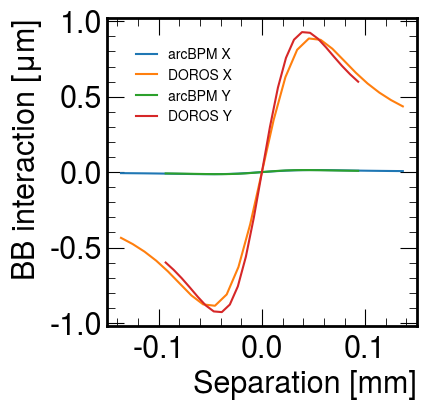

In [19]:
#control plot for BB
fig, ax = plt.subplots(figsize=(4,4))
plt.xlabel("Separation [mm]")
plt.ylabel("BB interaction [$\mu m$]")
vdmscan = list(filter(lambda x: x.startswith('vdM'), list(data_array.keys()))) #first VdM scan in the fill
ax.plot(np.array(data_array[vdmscan[0]]['setX1'])-np.array(data_array[vdmscan[0]]['setX2']),np.array(data_array[vdmscan[0]]['bbshiftarcX1'])*1000,label='arcBPM X')
ax.plot(np.array(data_array[vdmscan[0]]['setX1'])-np.array(data_array[vdmscan[0]]['setX2']),np.array(data_array[vdmscan[0]]['bbshiftdorosX1'])*1000,label='DOROS X')
ax.plot(np.array(data_array[vdmscan[1]]['setY1'])-np.array(data_array[vdmscan[1]]['setY2']),np.array(data_array[vdmscan[1]]['bbshiftarcY1'])*1000,label='arcBPM Y')
ax.plot(np.array(data_array[vdmscan[1]]['setY1'])-np.array(data_array[vdmscan[1]]['setY2']),np.array(data_array[vdmscan[1]]['bbshiftdorosY1'])*1000,label='DOROS Y')

plt.legend(loc='upper left',prop={'size': 10}, bbox_to_anchor=(0.05, 0.95))

In [20]:
def f(nom, bb, alpha, beta, const) : #scanning plane fit function
    return alpha*nom + bb*beta + const
def fOOP(nom, bb, alpha, beta, gamma, constOOP) : #off axis fit function
    return gamma*nom + beta*(gamma/alpha)*bb + constOOP

def residual(params, x_array, bb_array, datainplane, dataOOP, datainplaneErr, dataOOPErr) : #define the residual for the minimizer
    simresid = []
    for i in range (0,len(x_array)) :
        x = np.array(x_array[i])
        bb = np.array(bb_array[i])
        inplane = np.array(datainplane[i])
        ooplane = np.array(dataOOP[i])
        inplaneErr = np.array(datainplaneErr[i])
        ooplaneErr = np.array(dataOOPErr[i])
        alpha = params['alpha_%i'%(i+1)].value #fit parameters
        beta = params['beta_%i'%(i+1)].value
        gamma = params['gamma_%i'%(i+1)].value
        const = params['const_%i'%(i+1)].value
        constOOP = params['constOOP_%i'%(i+1)].value
        inplaneres = (inplane - f(x,bb,alpha,beta,const)) / inplaneErr
        if params['gamma_%i'%(i+1)].vary == True or params['gamma_%i'%(i+1)].expr == 'gamma_1' : ooplaneres = (ooplane - fOOP(x,bb,alpha,beta,gamma,constOOP)) / ooplaneErr
        else : ooplaneres = fOOP(x,bb,alpha,beta,gamma,constOOP) #no OOP data for diag return model
        simresid.extend(inplaneres) #simultaneous fit for scanning and off axis
        simresid.extend(ooplaneres)
    return np.array(simresid)

In [21]:
#fill the lists with the required data
scan_names = {}
non_moving = {}
all_moving = {}
x_array = {}
bb_array = {}
datainplane = {}
dataOOP = {}
for scan in data_array :
    for beam in range(1,3) : #beam 1 or 2
        for plane in range(0,len(planes)) : #plane X or Y
            #if (data_array[scan]['beam'] == 0 or data_array[scan]['beam'] == beam) and (data_array[scan]['axis'] == 0 or data_array[scan]['axis'] == plane+1) :
            if (data_array[scan]['axis'] == 0 or data_array[scan]['axis'] == plane+1) :
                coord = planes[plane] + str(beam)
                coordOOP = planes[0 if plane == 1 else 1] + str(beam)
                scan_names.setdefault(coord,[]).append(scan)
                non_moving.setdefault(coord,[]).append(False if (data_array[scan]['beam'] == 0 or data_array[scan]['beam'] == beam) else True)
                all_moving.setdefault(coord,[]).append(True if (data_array[scan]['beam'] == 0 and data_array[scan]['axis'] == 0) else False)
                x_array.setdefault('set' + coord,[]).append(data_array[scan]['set' + coord])
                if(data_array[scan].get('subscan') == 'vdM' or data_array[scan].get('subscan') == 'im') : #only vdM + BI data for fits
                    scan_names.setdefault(coord + 'vdM',[]).append(scan)
                    non_moving.setdefault(coord + 'vdM',[]).append(False if (data_array[scan]['beam'] == 0 or data_array[scan]['beam'] == beam) else True)
                    all_moving.setdefault(coord + 'vdM',[]).append(True if (data_array[scan]['beam'] == 0 and data_array[scan]['axis'] == 0) else False)
                    x_array.setdefault('set' + coord + 'vdM',[]).append(data_array[scan]['set' + coord])                   
                for bpm in bpms : #arc or doros
                    bb_array.setdefault(bpm + coord,[]).append(data_array[scan]['bbshift' + bpm + coord])
                    datainplane.setdefault(bpm + coord,[]).append(data_array[scan][bpm + coord])
                    dataOOP.setdefault(bpm + coordOOP,[]).append(data_array[scan][bpm + coordOOP])
                    datainplane.setdefault(bpm + coord + 'Err',[]).append(data_array[scan][bpm + 'err' + coord])
                    dataOOP.setdefault(bpm + coordOOP + 'Err',[]).append(data_array[scan][bpm + 'err' + coordOOP])
                    if(data_array[scan].get('subscan') == 'vdM' or data_array[scan].get('subscan') == 'im') : #only vdM data for fits
                        bb_array.setdefault(bpm + coord + 'vdM',[]).append(data_array[scan]['bbshift' + bpm + coord])
                        datainplane.setdefault(bpm + coord + 'vdM',[]).append(data_array[scan][bpm + coord])
                        dataOOP.setdefault(bpm + coordOOP + 'vdM',[]).append(data_array[scan][bpm + coordOOP])
                        datainplane.setdefault(bpm + coord + 'Err' + 'vdM',[]).append(data_array[scan][bpm + 'err' + coord])
                        dataOOP.setdefault(bpm + coordOOP + 'Err' + 'vdM',[]).append(data_array[scan][bpm + 'err' + coordOOP])

In [22]:
fit_params = {}
fit_results = {}

In [23]:
# Check what keys exist in scan_names
print("Keys in scan_names:")
print(list(scan_names.keys()))
print()

# Check what coord is
print(f"Current coord value: '{coord}'")
print(f"Looking for key: '{coord}vdM'")
print()

# Check if the key exists
if coord + 'vdM' in scan_names:
    print(f"✓ Key '{coord}vdM' exists")
    print(f"  Value: {scan_names[coord + 'vdM']}")
else:
    print(f"✗ Key '{coord}vdM' does NOT exist")
    print(f"  Available keys: {list(scan_names.keys())}")

Keys in scan_names:
['X1', 'X1vdM', 'X2', 'X2vdM', 'Y1', 'Y1vdM', 'Y2', 'Y2vdM']

Current coord value: 'Y2'
Looking for key: 'Y2vdM'

✓ Key 'Y2vdM' exists
  Value: ['vdM_0_2_1', 'vdM_0_2_4', 'vdM_0_2_9']


In [24]:
# fit the separate results
method = 'Sep'
fit_params[method] = {}
fit_results[method] = {}
for beam in range(1,3) : #beam 1 or 2
    for plane in range(0,len(planes)) : #plane X or Y
        coord = planes[plane] + str(beam)
        coordOOP = planes[0 if plane == 1 else 1] + str(beam)
        for bpm in bpms : #arc or doros
            fit_params[method].setdefault(bpm + coord,Parameters())
            for i in range(0,len(scan_names[coord])):
                fit_params[method][bpm + coord].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord][i] is True) : fit_params[method][bpm + coord]['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord][i] is True or all_moving[coord][i] is True) : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord][i] is True) : fit_params[method][bpm + coord]['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord])): #define shared parameters
                if fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord] = minimize(residual, fit_params[method][bpm + coord], args=(x_array['set' + coord], bb_array[bpm + coord], datainplane[bpm + coord], dataOOP[bpm + coordOOP], datainplane[bpm + coord + 'Err'], dataOOP[bpm + coordOOP + 'Err']))

            fit_params[method].setdefault(bpm + coord + 'vdM',Parameters())
            for i in range(0,len(scan_names[coord + 'vdM'])):
                fit_params[method][bpm + coord + 'vdM'].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord + 'vdM'].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord + 'vdM'].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord + 'vdM'][i] is True or all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord + 'vdM'])): #define shared parameters
                if fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord + 'vdM'] = minimize(residual, fit_params[method][bpm + coord + 'vdM'], args=(x_array['set' + coord + 'vdM'], bb_array[bpm + coord + 'vdM'], datainplane[bpm + coord + 'vdM'], dataOOP[bpm + coordOOP + 'vdM'], datainplane[bpm + coord + 'ErrvdM'], dataOOP[bpm + coordOOP + 'ErrvdM']))

/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_co

In [25]:
# fit the common LS results
method = 'CommonLS'
fit_params[method] = {}
fit_results[method] = {}
for beam in range(1,3) : #beam 1 or 2
    for plane in range(0,len(planes)) : #plane X or Y
        coord = planes[plane] + str(beam)
        coordOOP = planes[0 if plane == 1 else 1] + str(beam)
        for bpm in bpms : #arc or doros
            fit_params[method].setdefault(bpm + coord,Parameters())
            for i in range(0,len(scan_names[coord])) :
                fit_params[method][bpm + coord].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord][i] is True) : fit_params[method][bpm + coord]['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord][i] is True or all_moving[coord][i] is True) : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord][i] is True) : fit_params[method][bpm + coord]['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord])): #define shared parameters
                if fit_params[method][bpm + coord]['alpha_%i' % (i+1)].vary is True : fit_params[method][bpm + coord]['alpha_%i' % (i+1)].expr = 'alpha_1'
                if fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord] = minimize(residual, fit_params[method][bpm + coord], args=(x_array['set' + coord], bb_array[bpm + coord], datainplane[bpm + coord], dataOOP[bpm + coordOOP], datainplane[bpm + coord + 'Err'], dataOOP[bpm + coordOOP + 'Err']))

            fit_params[method].setdefault(bpm + coord + 'vdM',Parameters())
            for i in range(0,len(scan_names[coord + 'vdM'])) :
                fit_params[method][bpm + coord + 'vdM'].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord + 'vdM'].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord + 'vdM'].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord + 'vdM'][i] is True or all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord + 'vdM'])): #define shared parameters
                if fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].vary is True : fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].expr = 'alpha_1'
                if fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord + 'vdM'] = minimize(residual, fit_params[method][bpm + coord + 'vdM'], args=(x_array['set' + coord + 'vdM'], bb_array[bpm + coord + 'vdM'], datainplane[bpm + coord + 'vdM'], dataOOP[bpm + coordOOP + 'vdM'], datainplane[bpm + coord + 'ErrvdM'], dataOOP[bpm + coordOOP + 'ErrvdM']))             

/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_co

In [26]:
# fit the common BB results
method = 'CommonBB'
fit_params[method] = {}
fit_results[method] = {}
for beam in range(1,3) : #beam 1 or 2
    for plane in range(0,len(planes)) : #plane X or Y
        coord = planes[plane] + str(beam)
        coordOOP = planes[0 if plane == 1 else 1] + str(beam)
        for bpm in bpms : #arc or doros
            fit_params[method].setdefault(bpm + coord,Parameters())
            for i in range(0,len(scan_names[coord])):
                fit_params[method][bpm + coord].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord][i] is True) : fit_params[method][bpm + coord]['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord][i] is True or all_moving[coord][i] is True) : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord][i] is True) : fit_params[method][bpm + coord]['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord])): #define shared parameters
                fit_params[method][bpm + coord]['beta_%i' % (i+1)].expr = 'beta_1'
                if fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord] = minimize(residual, fit_params[method][bpm + coord], args=(x_array['set' + coord], bb_array[bpm + coord], datainplane[bpm + coord], dataOOP[bpm + coordOOP], datainplane[bpm + coord + 'Err'], dataOOP[bpm + coordOOP + 'Err']))

            fit_params[method].setdefault(bpm + coord + 'vdM',Parameters())
            for i in range(0,len(scan_names[coord + 'vdM'])):
                fit_params[method][bpm + coord + 'vdM'].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord + 'vdM'].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord + 'vdM'].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord + 'vdM'][i] is True or all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord + 'vdM'])): #define shared parameters
                fit_params[method][bpm + coord + 'vdM']['beta_%i' % (i+1)].expr = 'beta_1'
                if fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord + 'vdM'] = minimize(residual, fit_params[method][bpm + coord + 'vdM'], args=(x_array['set' + coord + 'vdM'], bb_array[bpm + coord + 'vdM'], datainplane[bpm + coord + 'vdM'], dataOOP[bpm + coordOOP + 'vdM'], datainplane[bpm + coord + 'ErrvdM'], dataOOP[bpm + coordOOP + 'ErrvdM']))

/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_co

In [27]:
# fit the common LS and BB results
method = 'CommonLSBB'
fit_params[method] = {}
fit_results[method] = {}
for beam in range(1,3) : #beam 1 or 2
    for plane in range(0,len(planes)) : #plane X or Y
        coord = planes[plane] + str(beam)
        coordOOP = planes[0 if plane == 1 else 1] + str(beam)
        for bpm in bpms : #arc or doros
            fit_params[method].setdefault(bpm + coord,Parameters())
            for i in range(0,len(scan_names[coord])):
                fit_params[method][bpm + coord].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord][i] is True) : fit_params[method][bpm + coord]['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord][i] is True or all_moving[coord][i] is True) : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord][i] is True) : fit_params[method][bpm + coord]['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord])): #define shared parameters
                if fit_params[method][bpm + coord]['alpha_%i' % (i+1)].vary is True : fit_params[method][bpm + coord]['alpha_%i' % (i+1)].expr = 'alpha_1'
                fit_params[method][bpm + coord]['beta_%i' % (i+1)].expr = 'beta_1'
                if fit_params[method][bpm + coord]['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord]['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord] = minimize(residual, fit_params[method][bpm + coord], args=(x_array['set' + coord], bb_array[bpm + coord], datainplane[bpm + coord], dataOOP[bpm + coordOOP], datainplane[bpm + coord + 'Err'], dataOOP[bpm + coordOOP + 'Err']))

            fit_params[method].setdefault(bpm + coord + 'vdM',Parameters())
            for i in range(0,len(scan_names[coord + 'vdM'])):
                fit_params[method][bpm + coord + 'vdM'].add( 'alpha_%i' % (i+1), value=1., min=0.9,  max=1.1)
                if(non_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'beta_%i' % (i+1), value=1.0)  # beta is linear; the old +/-3 bound clipped arcBPM PbPb fits
                fit_params[method][bpm + coord + 'vdM'].add( 'const_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                fit_params[method][bpm + coord + 'vdM'].add( 'gamma_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(non_moving[coord + 'vdM'][i] is True or all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary = False
                fit_params[method][bpm + coord + 'vdM'].add( 'constOOP_%i' % (i+1), value=0.0, min=-0.5, max=0.5)
                if(all_moving[coord + 'vdM'][i] is True) : fit_params[method][bpm + coord + 'vdM']['constOOP_%i' % (i+1)].vary = False
            for i in range(1,len(scan_names[coord + 'vdM'])): #define shared parameters
                if fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].vary is True : fit_params[method][bpm + coord + 'vdM']['alpha_%i' % (i+1)].expr = 'alpha_1'
                fit_params[method][bpm + coord + 'vdM']['beta_%i' % (i+1)].expr = 'beta_1'
                if fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].vary is True : fit_params[method][bpm + coord + 'vdM']['gamma_%i' % (i+1)].expr = 'gamma_1'
            fit_results[method][bpm + coord + 'vdM'] = minimize(residual, fit_params[method][bpm + coord + 'vdM'], args=(x_array['set' + coord + 'vdM'], bb_array[bpm + coord + 'vdM'], datainplane[bpm + coord + 'vdM'], dataOOP[bpm + coordOOP + 'vdM'], datainplane[bpm + coord + 'ErrvdM'], dataOOP[bpm + coordOOP + 'ErrvdM']))


/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():
/home/jesusavc/anaconda3/lib/python3.13/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_co

In [28]:
# Verify covariance errors for all free parameters used by the summary plots.
# A fixed parameter has no fitted uncertainty. A parameter constrained by an
# equality such as beta_i = beta_1 inherits the master's uncertainty.
missing_fit_errors = []
for fit_type, results in fit_results.items():
    for fit_name, result in results.items():
        for name, parameter in result.params.items():
            if not name.startswith(('alpha_', 'beta_')):
                continue
            if parameter.expr in ('alpha_1', 'beta_1') and parameter.stderr is None:
                parameter.stderr = result.params[parameter.expr].stderr
            if parameter.vary and parameter.expr is None and (
                    parameter.stderr is None or not np.isfinite(parameter.stderr)
                    or parameter.stderr <= 0):
                missing_fit_errors.append(
                    f'{fit_type}/{fit_name}/{name}: value={parameter.value:.4g}, '
                    f'errorbars={result.errorbars}, redchi={result.redchi:.4g}, '
                    f'message={result.message}')
if missing_fit_errors:
    raise RuntimeError(
        'lmfit could not estimate uncertainties for free fit parameters. '
        'Inspect the fits before calculating ROD or plotting:\n  '
        + '\n  '.join(missing_fit_errors)
    )

#average of the fitted BB deflection magnitudes
def averagebb(result, label):
    # Count each free beta once: beta_i with expr='beta_1' repeats beta_1.
    betas = [(name, par) for name, par in result.params.items()
             if name.startswith('beta_') and par.expr is None]
    if not betas:
        raise ValueError(f'{label}: no independent beta parameters')
    values = np.array([par.value for _, par in betas], dtype=float)
    if not np.all(np.isfinite(values)):
        raise ValueError(f'{label}: nonfinite beta fit value')
    if len(betas) == 1:
        return float(values[0])
    errors = np.array([np.nan if par.stderr is None else par.stderr
                       for _, par in betas], dtype=float)
    if np.all(np.isfinite(errors) & (errors > 0)):
        return float(np.average(values, weights=1/errors**2))
    missing = [name for (name, _), err in zip(betas, errors)
               if not np.isfinite(err) or err <= 0]
    raise ValueError(f'{label}: cannot calculate an inverse-variance beta mean; '
                     f'missing or invalid uncertainties for {missing}. '
                     'Inspect the fit covariance and parameter bounds.')

# Discard derived results from an earlier fit-cell run before writing fresh ones.
for _scan_data in data_array.values():
    for _fit_key in list(_scan_data):
        if any(_fit_key.startswith(_method + '_') for _method in fit_results):
            del _scan_data[_fit_key]

#save fit parameters and residuals
for fittype in fit_results :
    for beam in range(1,3) : #beam 1 or 2
        for plane in range(0,len(planes)) : #plane X or Y
            coord = planes[plane] + str(beam)
            coordOOP = planes[0 if plane == 1 else 1] + str(beam)
            for bpm in bpms : #arc or doros
                meanbb = averagebb(fit_results[fittype][bpm + coord], f'{fittype}/{bpm}{coord}')
                for i in range(0,len(scan_names[coord])):
                    scan = scan_names[coord][i]
                    correlation = 0.
                    if fittype == 'CommonLSBB' and fit_results[fittype][bpm + coord].params['alpha_1'].correl is not None :
                        correlation = fit_results[fittype][bpm + coord].params['alpha_1'].correl.get('beta_1', 0.)
                    if fit_results[fittype][bpm + coord].params['alpha_%i' % (i+1)].correl is not None :
                        if fittype == 'CommonBB' : correlation = fit_results[fittype][bpm + coord].params['alpha_%i' % (i+1)].correl['beta_1']
                    if fit_results[fittype][bpm + coord].params['beta_%i' % (i+1)].correl is not None :
                        if fittype == 'CommonLS' : correlation = fit_results[fittype][bpm + coord].params['alpha_1'].correl['beta_%i' % (i+1)]
                    if fit_results[fittype][bpm + coord].params['beta_%i' % (i+1)].correl is not None and fit_results[fittype][bpm + coord].params['alpha_%i' % (i+1)].correl is not None :
                        if fittype == 'Sep' : correlation = fit_results[fittype][bpm + coord].params['alpha_%i' % (i+1)].correl['beta_%i' % (i+1)]
                    redchi = fit_results[fittype][bpm + coord].redchi
                    chi2_val = fit_results[fittype][bpm + coord].chisqr
                    ndof = fit_results[fittype][bpm + coord].ndata - fit_results[fittype][bpm + coord].nvarys
                    pval = 1 - chi2.cdf(chi2_val, df=ndof)
                    alpha = fit_results[fittype][bpm + coord].params['alpha_%i' % (i+1)]
                    beta = fit_results[fittype][bpm + coord].params['beta_%i' % (i+1)]
                    gamma = fit_results[fittype][bpm + coord].params['gamma_%i' % (i+1)]
                    const = fit_results[fittype][bpm + coord].params['const_%i' % (i+1)]
                    constOOP = fit_results[fittype][bpm + coord].params['constOOP_%i' % (i+1)]
                    #store the fit parameters
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_correlation',correlation)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_redchi',redchi)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_chi2',chi2_val)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_ndof',ndof)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_pval',pval)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_alpha',alpha)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_beta',beta)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_gamma',gamma)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_const',const)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_constOOP',constOOP)
                    #calculate the residuals
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_res',np.array(data_array[scan][bpm + coord]) - f(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,const.value))
                    if (data_array[scan]['beam'] > 0 or data_array[scan]['axis'] > 0) : data_array[scan].setdefault(fittype + '_' + bpm + coordOOP + '_res',np.array(data_array[scan][bpm + coordOOP]) - fOOP(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,gamma.value,constOOP.value))
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_res_noconst',np.array(data_array[scan][bpm + coord]) - f(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,0.))
                    if (data_array[scan]['beam'] > 0 or data_array[scan]['axis'] > 0) : data_array[scan].setdefault(fittype + '_' + bpm + coordOOP + '_res_noconst',np.array(data_array[scan][bpm + coordOOP]) - fOOP(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,gamma.value,data_array[scan]['set' + coordOOP]))
                    data_array[scan].setdefault(fittype + '_averageBB_' + bpm + coord + '_res_noconst',np.array(data_array[scan][bpm + coord]) - f(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,meanbb,0.))
                    if (data_array[scan]['beam'] > 0 or data_array[scan]['axis'] > 0) : data_array[scan].setdefault(fittype + '_averageBB_' + bpm + coordOOP + '_res_noconst',np.array(data_array[scan][bpm + coordOOP]) - fOOP(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,meanbb,gamma.value,data_array[scan]['set' + coordOOP]))
                meanbbvdM = averagebb(fit_results[fittype][bpm + coord + 'vdM'], f'{fittype}/{bpm}{coord}vdM')
                for i in range(0,len(scan_names[coord + 'vdM'])):
                    scan = scan_names[coord + 'vdM'][i]
                    alpha = fit_results[fittype][bpm + coord + 'vdM'].params['alpha_%i' % (i+1)]
                    beta = fit_results[fittype][bpm + coord + 'vdM'].params['beta_%i' % (i+1)]
                    gamma = fit_results[fittype][bpm + coord + 'vdM'].params['gamma_%i' % (i+1)]
                    const = fit_results[fittype][bpm + coord + 'vdM'].params['const_%i' % (i+1)]
                    constOOP = fit_results[fittype][bpm + coord + 'vdM'].params['constOOP_%i' % (i+1)]
                    #store the fit parameters
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + 'vdM' + '_alpha',alpha)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + 'vdM' + '_beta',beta)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + 'vdM' + '_gamma',gamma)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + 'vdM' + '_const',const)
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + 'vdM' + '_constOOP',constOOP)
                    #calculate the residuals
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_vdM_res',np.array(data_array[scan][bpm + coord]) - f(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,const.value))
                    if (data_array[scan]['beam'] > 0 or data_array[scan]['axis'] > 0) : data_array[scan].setdefault(fittype + '_' + bpm + coordOOP + '_vdM_res',np.array(data_array[scan][bpm + coordOOP]) - fOOP(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,gamma.value,constOOP.value))
                    data_array[scan].setdefault(fittype + '_' + bpm + coord + '_vdM_res_noconst',np.array(data_array[scan][bpm + coord]) - f(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,0.))
                    if (data_array[scan]['beam'] > 0 or data_array[scan]['axis'] > 0) : data_array[scan].setdefault(fittype + '_' + bpm + coordOOP + '_vdM_res_noconst',np.array(data_array[scan][bpm + coordOOP]) - fOOP(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,beta.value,gamma.value,data_array[scan]['set' + coordOOP]))
                    data_array[scan].setdefault(fittype + '_averageBB_' + bpm + coord + '_vdM_res_noconst',np.array(data_array[scan][bpm + coord]) - f(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,meanbb,0.))
                    if (data_array[scan]['beam'] > 0 or data_array[scan]['axis'] > 0) : data_array[scan].setdefault(fittype + '_averageBB_' + bpm + coordOOP + '_vdM_res_noconst',np.array(data_array[scan][bpm + coordOOP]) - fOOP(np.array(data_array[scan]['set' + coord]),np.array(data_array[scan]['bbshift' + bpm + coord]),alpha.value,meanbb,gamma.value,data_array[scan]['set' + coordOOP]))

In [29]:
# Search for where 'Sep_averageBB_' keys are supposed to be created
# Look for code that does something like:
# data_array[scan]['Sep_averageBB_' + bpm + 'X1_res_noconst'] = ...

# Debug: Check if ANY of these keys exist
print("Checking if Sep_averageBB keys exist...")
scan = list(data_array.keys())[0]
bpm = 'doros'

test_keys = [
    f'Sep_averageBB_{bpm}X1_res_noconst',
    f'Sep_averageBB_{bpm}X2_res_noconst',
    f'Sep_averageBB_{bpm}Y1_res_noconst',
    f'Sep_averageBB_{bpm}Y2_res_noconst'
]

for key in test_keys:
    exists = key in data_array[scan]
    print(f"  {key}: {'✓ EXISTS' if exists else '✗ MISSING'}")

print("\n" + "="*60)
print("Keys that DO exist with 'averageBB' in them:")
avgbb_keys = [k for k in data_array[scan].keys() if 'averageBB' in k]
if avgbb_keys:
    for key in avgbb_keys:
        print(f"  - {key}")
else:
    print("  (none found)")

print("\n" + "="*60)
print("Keys that DO exist with 'res_noconst' in them:")
res_keys = [k for k in data_array[scan].keys() if 'res_noconst' in k]
if res_keys:
    for key in res_keys:
        print(f"  - {key}")
else:
    print("  (none found)")

Checking if Sep_averageBB keys exist...
  Sep_averageBB_dorosX1_res_noconst: ✓ EXISTS
  Sep_averageBB_dorosX2_res_noconst: ✓ EXISTS
  Sep_averageBB_dorosY1_res_noconst: ✓ EXISTS
  Sep_averageBB_dorosY2_res_noconst: ✓ EXISTS

Keys that DO exist with 'averageBB' in them:
  - Sep_averageBB_dorosX1_res_noconst
  - Sep_averageBB_dorosY1_res_noconst
  - Sep_averageBB_dorosX1_vdM_res_noconst
  - Sep_averageBB_dorosY1_vdM_res_noconst
  - Sep_averageBB_arcX1_res_noconst
  - Sep_averageBB_arcY1_res_noconst
  - Sep_averageBB_arcX1_vdM_res_noconst
  - Sep_averageBB_arcY1_vdM_res_noconst
  - Sep_averageBB_dorosX2_res_noconst
  - Sep_averageBB_dorosY2_res_noconst
  - Sep_averageBB_dorosX2_vdM_res_noconst
  - Sep_averageBB_dorosY2_vdM_res_noconst
  - Sep_averageBB_arcX2_res_noconst
  - Sep_averageBB_arcY2_res_noconst
  - Sep_averageBB_arcX2_vdM_res_noconst
  - Sep_averageBB_arcY2_vdM_res_noconst
  - CommonLS_averageBB_dorosX1_res_noconst
  - CommonLS_averageBB_dorosY1_res_noconst
  - CommonLS_average

In [30]:
#write per step residuals into file original without the 2D
os.makedirs(PATH + 'resod_files_fill' + fill + '/', exist_ok=True)

files = []
folders = {'all': []}
for scan in data_array :
    folder = data_array[scan].get('folder')
    folders['all'].append(folder) if folder not in folders['all'] else None

fieldnames = ['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y']
for bpm in bpms :
    for method in fit_results :
        #open the file
        with open(PATH + 'resod_files_fill' + fill + '/' + method + '_fill' + fill + '_' + bpm + '.csv', 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y'])
            for folder in folders['all'] :
                #for plane in range(1,3) :
                xcorrections = []
                ycorrections = []
                for scan in data_array :
                    if folder == data_array[scan]['folder'] : #and plane == data_array[scan]['axis']
                        len(xcorrections)
                        xcorrections.extend((data_array[scan][method + '_' + bpm + 'X1_res_noconst'] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'])*1000)
                        ycorrections.extend((data_array[scan][method + '_' + bpm + 'Y1_res_noconst'] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'])*1000)
                steps = int(len(xcorrections)/2)
                for i in range (0,steps) :
                    writer.writerow([folder,1,i,xcorrections[i],ycorrections[i]])
                for i in range (0,steps) :
                    writer.writerow([folder,2,i,xcorrections[steps+i],ycorrections[steps+i]])
    with open(PATH + 'resod_files_fill' + fill + '/averageBB_fill' + fill + '_' + bpm + '.csv', 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y'])
        for folder in folders['all'] :
            #for plane in range(1,3) :
            xcorrections = []
            ycorrections = []
            for scan in data_array :
                if folder == data_array[scan]['folder'] : #and plane == data_array[scan]['axis']
                    xcorrections.extend((data_array[scan]['Sep_averageBB_' + bpm + 'X1_res_noconst'] - data_array[scan]['Sep_averageBB_' + bpm + 'X2_res_noconst'])*1000)
                    ycorrections.extend((data_array[scan]['Sep_averageBB_' + bpm + 'Y1_res_noconst'] - data_array[scan]['Sep_averageBB_' + bpm + 'Y2_res_noconst'])*1000)
            steps = int(len(xcorrections)/2)
            for i in range (0,steps) :
                writer.writerow([folder,1,i,xcorrections[i],ycorrections[i]])
            for i in range (0,steps) :
                writer.writerow([folder,2,i,xcorrections[steps+i],ycorrections[steps+i]])

In [31]:
#write per step residuals into file
files = []
folders = {'all': []}
for scan in data_array :
    folder = data_array[scan].get('folder')
    folders['all'].append(folder) if folder not in folders['all'] else None

fieldnames = ['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y']
for bpm in bpms :
    for method in fit_results :
        #open the file
        with open(PATH + 'resod_files_fill' + fill + '/' + method + '_fill' + fill + '_' + bpm + '.csv', 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y'])
            for folder in folders['all'] :
                if folder not in folderNames2D[fill]:
                    #for plane in range(1,3) :
                    xcorrections = []
                    ycorrections = []
                    for scan in data_array :
                        if folder == data_array[scan]['folder'] : #and plane == data_array[scan]['axis']
                            xcorrections.extend((data_array[scan][method + '_' + bpm + 'X1_res_noconst'] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'])*1000)
                            ycorrections.extend((data_array[scan][method + '_' + bpm + 'Y1_res_noconst'] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'])*1000)
                    steps = int(len(xcorrections)/2)
                    for i in range (0,steps) :
                        writer.writerow([folder,1,i,xcorrections[i],ycorrections[i]])
                    for i in range (0,steps) :
                        writer.writerow([folder,2,i,xcorrections[steps+i],ycorrections[steps+i]])
                else:
                    for scan in data_array :
                        if folder == data_array[scan]['folder'] : #and plane == data_array[scan]['axis']
                            middle = int(len(data_array[scan][method + '_' + bpm + 'X1_res_noconst'])/2)
                            referencex = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][51:60] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][51:60])*1000
                            referencey = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][51:60] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][51:60])*1000                        
                            for i in range(0,4) :
                                xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][i*9:i*9+9] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][i*9:i*9+9])*1000
                                ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][i*9:i*9+9] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][i*9:i*9+9])*1000
                                for j in range(0,len(xcorrections)) :
                                    writer.writerow([folderNames2D[fill][i],1,j,xcorrections[j],ycorrections[j]])
                                for j in range(0,len(referencex)) :
                                    writer.writerow([folderNames2D[fill][i],2,j,referencex[j],referencey[j]])
                            ### middle vdm like scan ###
                            xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][36:49] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][36:49])*1000
                            ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][36:49] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][36:49])*1000
                            for j in range(0,len(xcorrections)) :
                                writer.writerow([folderNames2D[fill][4],1,j,xcorrections[j],ycorrections[j]])
                            xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][49:62] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][49:62])*1000
                            ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][49:62] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][49:62])*1000
                            for j in range(0,len(xcorrections)) :
                                writer.writerow([folderNames2D[fill][4],2,j,xcorrections[j],ycorrections[j]])
                            for i in range(0,4) :
                                xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][62+i*9:62+i*9+9] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][62+i*9:62+i*9+9])*1000
                                ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][62+i*9:62+i*9+9] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][62+i*9:62+i*9+9])*1000
                                for j in range(0,len(referencex)) :
                                    writer.writerow([folderNames2D[fill][5+i],1,j,referencex[j],referencey[j]])
                                for j in range(0,len(xcorrections)) :
                                    writer.writerow([folderNames2D[fill][5+i],2,j,xcorrections[j],ycorrections[j]])                            
    #average BB results
    method = 'Sep_averageBB'
    with open(PATH + 'resod_files_fill' + fill + '/averageBB_fill' + fill + '_' + bpm + '.csv', 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y'])
        for folder in folders['all'] :
            if folder not in folderNames2D[fill]:
                #for plane in range(1,3) :
                xcorrections = []
                ycorrections = []
                for scan in data_array :
                    if folder == data_array[scan]['folder'] : #and plane == data_array[scan]['axis']
                        xcorrections.extend((data_array[scan][method + '_' + bpm + 'X1_res_noconst'] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'])*1000)
                        ycorrections.extend((data_array[scan][method + '_' + bpm + 'Y1_res_noconst'] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'])*1000)
                steps = int(len(xcorrections)/2)
                for i in range (0,steps) :
                    writer.writerow([folder,1,i,xcorrections[i],ycorrections[i]])
                for i in range (0,steps) :
                    writer.writerow([folder,2,i,xcorrections[steps+i],ycorrections[steps+i]])
            else:
                for scan in data_array :
                    if folder == data_array[scan]['folder'] : #and plane == data_array[scan]['axis']
                        middle = int(len(data_array[scan][method + '_' + bpm + 'X1_res_noconst'])/2)
                        referencex = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][51:60] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][51:60])*1000
                        referencey = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][51:60] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][51:60])*1000                        
                        for i in range(0,4) :
                            xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][i*9:i*9+9] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][i*9:i*9+9])*1000
                            ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][i*9:i*9+9] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][i*9:i*9+9])*1000
                            for j in range(0,len(xcorrections)) :
                                writer.writerow([folderNames2D[fill][i],1,j,xcorrections[j],ycorrections[j]])
                            for j in range(0,len(referencex)) :
                                writer.writerow([folderNames2D[fill][i],2,j,referencex[j],referencey[j]])
                        ### middle vdm like scan ###
                        xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][36:49] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][36:49])*1000
                        ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][36:49] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][36:49])*1000
                        for j in range(0,len(xcorrections)) :
                            writer.writerow([folderNames2D[fill][4],1,j,xcorrections[j],ycorrections[j]])
                        xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][49:62] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][49:62])*1000
                        ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][49:62] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][49:62])*1000
                        for j in range(0,len(xcorrections)) :
                            writer.writerow([folderNames2D[fill][4],2,j,xcorrections[j],ycorrections[j]])
                        for i in range(0,4) :
                            xcorrections = (data_array[scan][method + '_' + bpm + 'X1_res_noconst'][62+i*9:62+i*9+9] - data_array[scan][method + '_' + bpm + 'X2_res_noconst'][62+i*9:62+i*9+9])*1000
                            ycorrections = (data_array[scan][method + '_' + bpm + 'Y1_res_noconst'][62+i*9:62+i*9+9] - data_array[scan][method + '_' + bpm + 'Y2_res_noconst'][62+i*9:62+i*9+9])*1000
                            for j in range(0,len(referencex)) :
                                writer.writerow([folderNames2D[fill][5+i],1,j,referencex[j],referencey[j]])
                            for j in range(0,len(xcorrections)) :
                                writer.writerow([folderNames2D[fill][5+i],2,j,xcorrections[j],ycorrections[j]])                            
                       


In [32]:
files = []
folders = {'vdM': []}
for scan in scan_names['X1vdM'] :
    folder = data_array[scan].get('folder')
    folders['vdM'].append(folder) if folder not in folders['vdM'] else None

fieldnames = ['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y']
for bpm in bpms :
    #only vdM global fits
    for method in fit_results :
        #open the file
        with open(PATH + 'resod_files_fill' + fill + '/' + method + '_vdM_fill' + fill + '_' + bpm + '.csv', 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['scan_name', 'plane', 'scan_point', 'correction_x', 'correction_y'])
            for folder in folders['vdM'] :
                #for plane in range(1,3) :
                xcorrections = []
                ycorrections = []
                for scan in data_array :
                    if folder == data_array[scan]['folder'] : #and plane == data_array[scan]['axis']
                        len(xcorrections)
                        xcorrections.extend((data_array[scan][method + '_' + bpm + 'X1_vdM_res_noconst'] - data_array[scan][method + '_' + bpm + 'X2_vdM_res_noconst'])*1000)
                        ycorrections.extend((data_array[scan][method + '_' + bpm + 'Y1_vdM_res_noconst'] - data_array[scan][method + '_' + bpm + 'Y2_vdM_res_noconst'])*1000)
                steps = int(len(xcorrections)/2)
                for i in range (0,steps) :
                    writer.writerow([folder,1,i,xcorrections[i],ycorrections[i]])
                for i in range (0,steps) :
                    writer.writerow([folder,2,i,xcorrections[steps+i],ycorrections[steps+i]])

In [33]:
### helpers for uncertainty calculations ###
def fit_stderr(parameter):
    """Return the covariance error, or NaN for a fixed parameter."""
    error = parameter.stderr
    return np.nan if error is None or not np.isfinite(error) or error < 0 else float(error)


def valid_weighted_values(values, errors):
    values = np.asarray(values, dtype=float)
    errors = np.asarray([np.nan if error is None else error for error in errors], dtype=float)
    if values.shape != errors.shape:
        raise ValueError('values and errors must have matching shapes')
    valid = np.isfinite(values) & np.isfinite(errors) & (errors > 0)
    return values[valid], errors[valid]


def weighted_avg(values, errors):
    values, errors = valid_weighted_values(values, errors)
    if not len(values):
        print('WARNING: no finite positive fit uncertainties; omitting weighted average')
        return np.nan
    return float(np.average(values, weights=1/errors**2))


def mean_error(errors):
    square = sum(errors**2)
    return np.sqrt(square) / len(errors)


def weighted_avg_and_error(values, errors):
    values, errors = valid_weighted_values(values, errors)
    if not len(values):
        print('WARNING: no finite positive fit uncertainties; omitting weighted average')
        return np.nan, np.nan
    weights = 1/errors**2
    return float(np.average(values, weights=weights)), float(np.sqrt(1/np.sum(weights)))

def eom(values) :
    mean = np.mean(values)
    std_dev = np.std(values, ddof=1)
    n = len(values)
    sem = std_dev / np.sqrt(n)
    return sem    
    
def weighted_std(values, errors):
    values, errors = valid_weighted_values(values, errors)
    if not len(values):
        print('WARNING: no finite positive fit uncertainties; omitting weighted spread')
        return np.nan
    weights = 1/errors**2
    weighted_mean = np.average(values, weights=weights)
    return float(np.sqrt(np.average((values - weighted_mean)**2, weights=weights)))


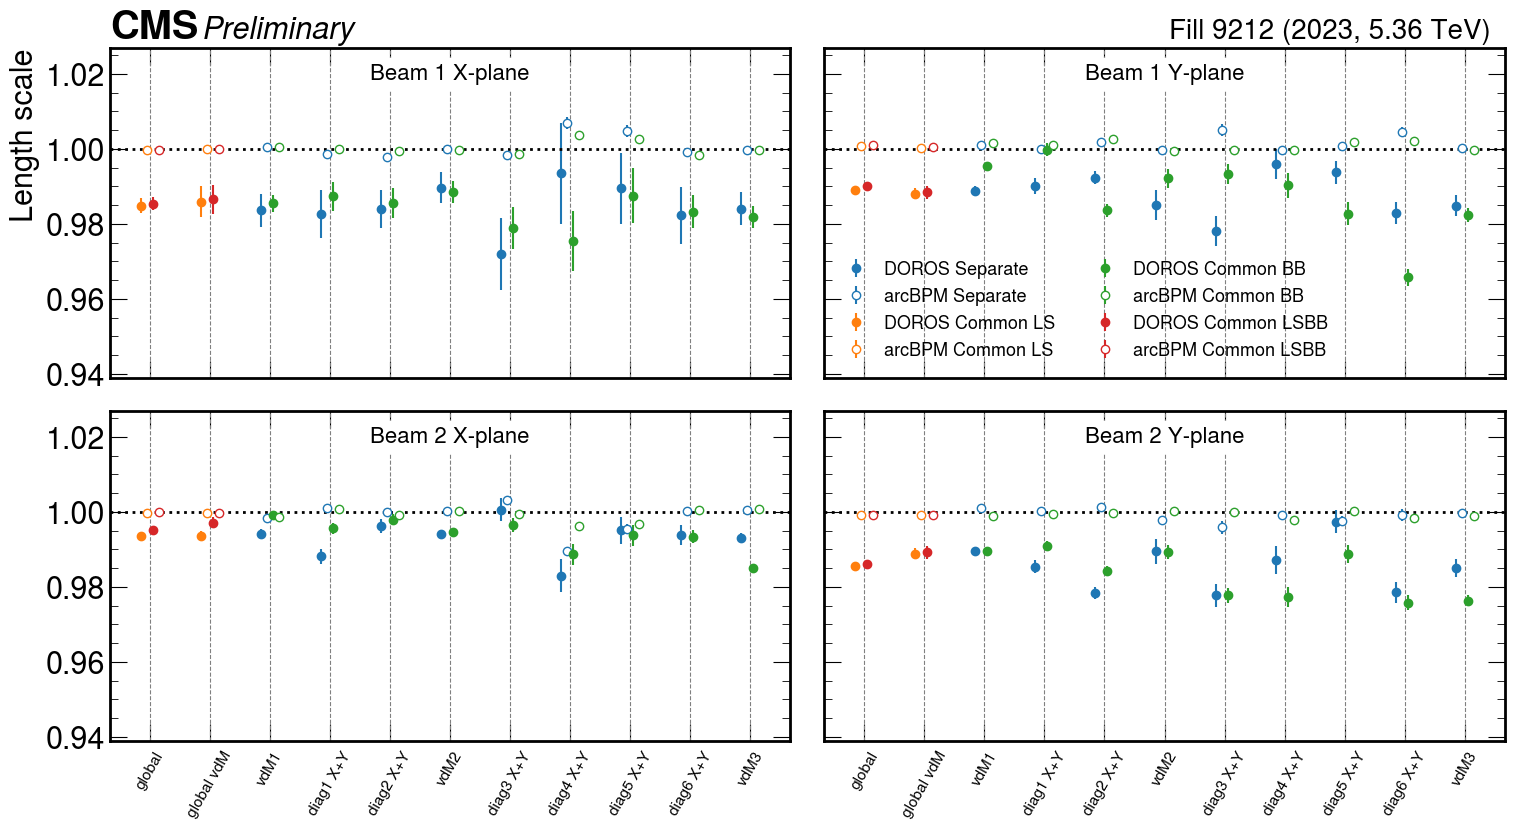

In [47]:
### merged length-scale plots (for AN and approval) ###
cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

#fitted LS plots
param = 'alpha'
subplots = ['X1','Y1','X2','Y2']
#figure = plt.figure()
fig, ax = plt.subplots(2,2,figsize=(18, 9),sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.05, hspace=0.1)
ax = ax.flatten()
plt.gca().xaxis.set_minor_locator(plt.NullLocator())
hep.cms.text(cmstext,fontsize=22,ax=ax[0])
#hep.cms.label("",exp="",data=True, ax=ax, year=year[fill], energy=cm[fill])
ax[1].text(0.98, 1.01, filltext,
                        horizontalalignment='right',
                        verticalalignment='bottom',
                        transform=ax[1].transAxes,
                        fontname='sans-serif',
                        color="k",
                        fontsize=20)  
for i in range(0,len(subplots)) :
    dorosFits = {}
    arcFits = {}
    xticks = ['global','global vdM']
    for scan in data_array :
        if data_array[scan].get('Sep_doros' + subplots[i] + '_' + param) != None :
            if data_array[scan]['typenr'] > 0 :
                label = data_array[scan].get('subscan') + str(data_array[scan].get('typenr'))
                if label.startswith('diag X+Y') :
                    label = label.replace(' X+Y','')
                    label += ' X+Y'
                if label.startswith('diag X-Y') :
                    label = label.replace(' X-Y','')
                    label += ' X-Y'
            else : label = data_array[scan].get('subscan')
            xticks.append(label)
            for method in fit_results :
                dorosFits.setdefault(method,[]).append(data_array[scan][method + '_doros' + subplots[i] + '_' + param].value)
                dorosFits.setdefault(method + 'Err',[]).append(fit_stderr(data_array[scan][method + '_doros' + subplots[i] + '_' + param]))
                arcFits.setdefault(method,[]).append(data_array[scan][method + '_arc' + subplots[i] + '_' + param].value)
                arcFits.setdefault(method + 'Err',[]).append(fit_stderr(data_array[scan][method + '_arc' + subplots[i] + '_' + param]))
                if data_array[scan].get('subscan') == 'vdM' and data_array[scan].get(method + '_doros' + subplots[i] + 'vdM_' + param) != None:
                    dorosFits.setdefault(method + 'vdM',[]).append(data_array[scan][method + '_doros' + subplots[i] + 'vdM_' + param].value)
                    dorosFits.setdefault(method + 'vdMErr',[]).append(fit_stderr(data_array[scan][method + '_doros' + subplots[i] + 'vdM_' + param]))
                    arcFits.setdefault(method + 'vdM',[]).append(data_array[scan][method + '_arc' + subplots[i] + 'vdM_' + param].value)
                    arcFits.setdefault(method + 'vdMErr',[]).append(fit_stderr(data_array[scan][method + '_arc' + subplots[i] + 'vdM_' + param]))
    ticks = np.arange(0, len(dorosFits['Sep'])+2, 1)
    xarray = [j for j in range(2,len(dorosFits['Sep'])+2)]
    # Keep fixed alpha points; their yerr is NaN because no alpha was fitted.
    ### sep fits ###
    ax[i].errorbar(np.array(xarray)-0.15, np.array(dorosFits['Sep']),np.array(dorosFits['SepErr']),fmt ='o',color=colors[0],label='DOROS Separate')
    ax[i].errorbar(np.array(xarray)-0.05, np.array(arcFits['Sep']),np.array(arcFits['SepErr']),fmt ='o',mfc='w',color=colors[0],label='arcBPM Separate')
    ### global fits ###
    ax[i].errorbar(-0.15, dorosFits['CommonLS'][0], yerr=dorosFits['CommonLSErr'][0],fmt ='o',color=colors[1],label='DOROS Common LS')
    ax[i].errorbar(-0.05, arcFits['CommonLS'][0], yerr=arcFits['CommonLSErr'][0],fmt ='o',mfc='w',color=colors[1],label='arcBPM Common LS')
    ### common BB fits (here separate)
    ax[i].errorbar(np.array(xarray)+0.05, np.array(dorosFits['CommonBB']),np.array(dorosFits['CommonBBErr']),fmt ='o',color=colors[2],label='DOROS Common BB')
    ax[i].errorbar(np.array(xarray)+0.15, np.array(arcFits['CommonBB']),np.array(arcFits['CommonBBErr']),fmt ='o',mfc='w',color=colors[2],label='arcBPM Common BB')
    ax[i].errorbar(0.05, dorosFits['CommonLSBB'][0], yerr=dorosFits['CommonLSBBErr'][0],fmt ='o',color=colors[3],label='DOROS Common LSBB')
    ax[i].errorbar(0.15, arcFits['CommonLSBB'][0], yerr=arcFits['CommonLSBBErr'][0],fmt ='o',mfc='w',color=colors[3],label='arcBPM Common LSBB')
    ### global vdm only ###
    ax[i].errorbar(1-0.15, dorosFits['CommonLSvdM'][0], yerr=dorosFits['CommonLSvdMErr'][0],fmt ='o',color=colors[1])
    ax[i].errorbar(1-0.05, arcFits['CommonLSvdM'][0], yerr=arcFits['CommonLSvdMErr'][0],fmt ='o',mfc='w',color=colors[1])
    ax[i].errorbar(1+0.05, dorosFits['CommonLSBBvdM'][0], yerr=dorosFits['CommonLSBBvdMErr'][0],fmt ='o',color=colors[3])
    ax[i].errorbar(1+0.15, arcFits['CommonLSBBvdM'][0], yerr=arcFits['CommonLSBBvdMErr'][0],fmt ='o',mfc='w',color=colors[3])

if fill == '6868' : ax[0].set_ylim(0.971,1.015)
if fill == '8999' : ax[0].set_ylim(0.968,1.007)
if fill == '9626' : ax[0].set_ylim(0.959,1.007)
if fill == '9212' : ax[0].set_ylim(0.939,1.027)

### text labels ### 
for axis in ax:
    plt.sca(axis)
    plt.xticks(ticks, labels=np.array(xticks), rotation = 60, fontsize=11)

for i in range(0,len(subplots)) :
    ticks = ax[i].get_xticks()
    ax[i].axhline(y=1.0, color='black', linestyle='dotted', linewidth=2.0)
    for tick in ticks:
        ax[i].axvline(x=tick, color='gray', linestyle='--', linewidth=0.8)

### text beam + plane ###
ax[0].text(0.5,0.92,"Beam 1 X-plane",transform=ax[0].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))
ax[1].text(0.5,0.92,"Beam 1 Y-plane",transform=ax[1].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))
ax[2].text(0.5,0.92,"Beam 2 X-plane",transform=ax[2].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))
ax[3].text(0.5,0.92,"Beam 2 Y-plane",transform=ax[3].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))

ax[0].set_ylabel("Length scale", fontsize=22)
#if fill == 9639 : ax[1].legend(ncol=2,loc='center right',prop={'size':13})
#if fill == 9626 : ax[1].legend(ncol=2,loc='center right',prop={'size':13})
if year[fill] == 2023 : ax[1].legend(ncol=2,loc='lower left',prop={'size':13})
if year[fill] == 2017 : ax[0].legend(ncol=2,loc='lower right',prop={'size':13})
if year[fill] == 2018 : ax[0].legend(ncol=2,loc='lower right',prop={'size':13})
if year[fill] == 2024 : ax[0].legend(ncol=2,loc='lower left',prop={'size':8})

#plt.legend(bbox_to_anchor=(1.01, 0.75), ncol=1, loc="lower left", prop={'size': 16})
plt.savefig(PATH + 'figures_fill' + fill + '/length_scales_' + fill + '.pdf',bbox_inches='tight')
plt.savefig(PATH + 'figures_fill' + fill + '/length_scales_' + fill + '.png',bbox_inches='tight')

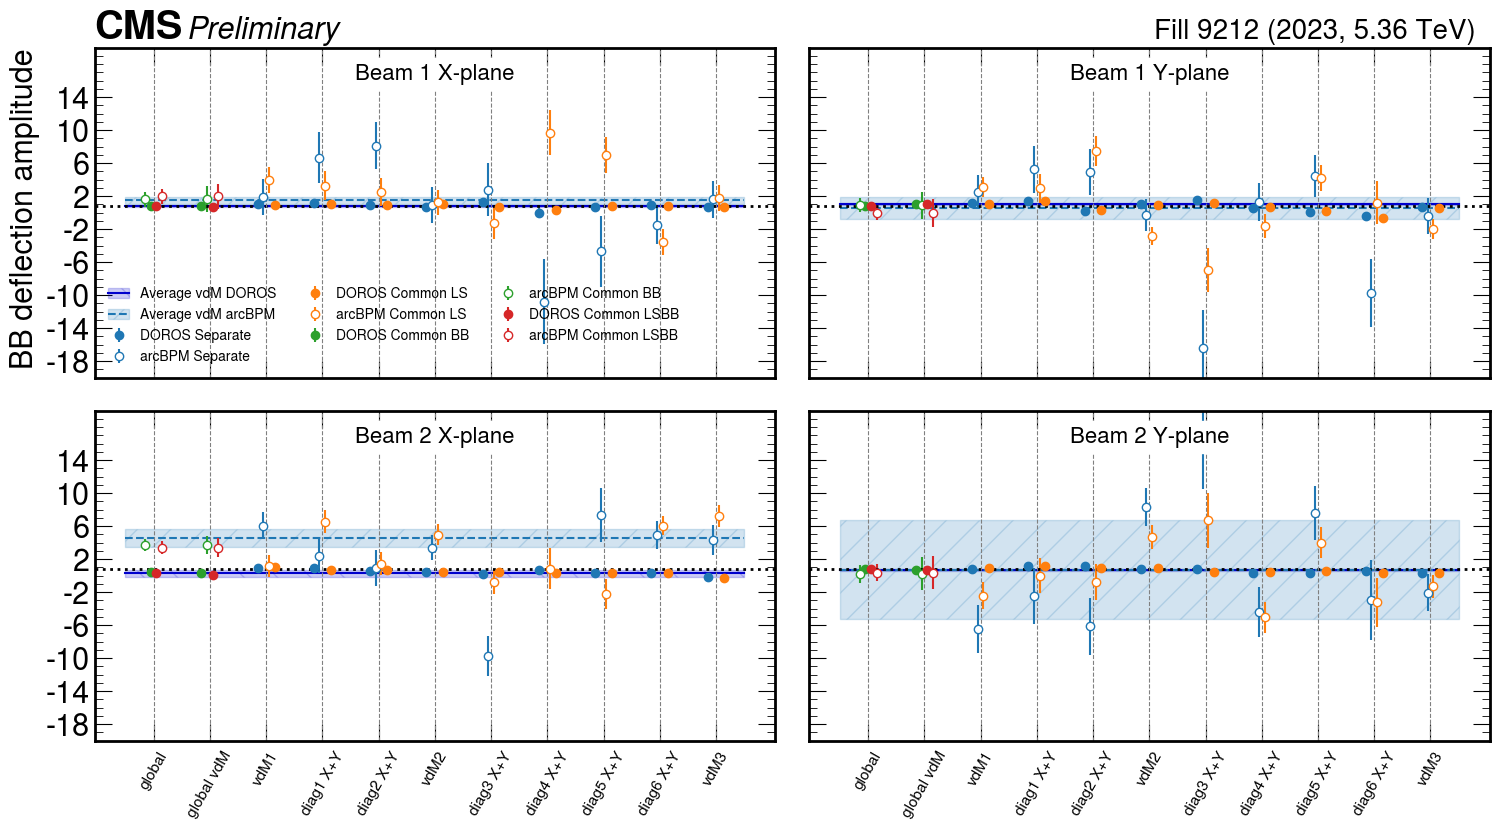

In [45]:
### merged bb plots (for AN and approval) ###
cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

#fitted LS plots
param = 'beta'
subplots = ['X1','Y1','X2','Y2']
#figure = plt.figure()
fig, ax = plt.subplots(2,2,figsize=(18, 9),sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.05, hspace=0.1)
ax = ax.flatten()
plt.gca().xaxis.set_minor_locator(plt.NullLocator())
plt.yticks(np.arange(-18, 18, 4))
hep.cms.text(cmstext,fontsize=22,ax=ax[0])
#hep.cms.label("",exp="",data=True, ax=ax, year=year[fill], energy=cm[fill])
ax[1].text(0.98, 1.01, filltext,
                        horizontalalignment='right',
                        verticalalignment='bottom',
                        transform=ax[1].transAxes,
                        fontname='sans-serif',
                        color="k",
                        fontsize=20)  
for i in range(0,len(subplots)) :
    dorosFits = {}
    arcFits = {}
    xticks = ['global','global vdM']
    for scan in data_array :
        if data_array[scan].get('Sep_doros' + subplots[i] + '_' + param) != None :
            if data_array[scan]['typenr'] > 0 :
                label = data_array[scan].get('subscan') + str(data_array[scan].get('typenr'))
                if label.startswith('diag X+Y') :
                    label = label.replace(' X+Y','')
                    label += ' X+Y'
                if label.startswith('diag X-Y') :
                    label = label.replace(' X-Y','')
                    label += ' X-Y'
            else : label = data_array[scan].get('subscan')
            xticks.append(label)           
            for method in fit_results :
                dorosFits.setdefault(method,[]).append(data_array[scan][method + '_doros' + subplots[i] + '_' + param].value)
                dorosFits.setdefault(method + 'Err',[]).append(fit_stderr(data_array[scan][method + '_doros' + subplots[i] + '_' + param]))
                arcFits.setdefault(method,[]).append(data_array[scan][method + '_arc' + subplots[i] + '_' + param].value)
                arcFits.setdefault(method + 'Err',[]).append(fit_stderr(data_array[scan][method + '_arc' + subplots[i] + '_' + param]))
                if data_array[scan].get('subscan') == 'vdM' and data_array[scan].get(method + '_doros' + subplots[i] + 'vdM_' + param) != None:
                    dorosFits.setdefault(method + 'vdM',[]).append(data_array[scan][method + '_doros' + subplots[i] + 'vdM_' + param].value)
                    dorosFits.setdefault(method + 'vdMErr',[]).append(fit_stderr(data_array[scan][method + '_doros' + subplots[i] + 'vdM_' + param]))
                    arcFits.setdefault(method + 'vdM',[]).append(data_array[scan][method + '_arc' + subplots[i] + '_' + param].value)
                    arcFits.setdefault(method + 'vdMErr',[]).append(fit_stderr(data_array[scan][method + '_arc' + subplots[i] + 'vdM_' + param]))
    ticks = np.arange(0, len(dorosFits['Sep'])+2, 1)
    xarray = [j for j in range(2,len(dorosFits['Sep'])+2)]
    ### calculate the averages for vdM scans only ###
    meanvdMdoros = weighted_avg(dorosFits['SepvdM'], dorosFits['SepvdMErr'])
    rmsvdMdoros = weighted_std(dorosFits['SepvdM'], dorosFits['SepvdMErr'])
    averagedorosline = ax[i].plot([-0.5,len(dorosFits['Sep'])+1.5],[meanvdMdoros,meanvdMdoros],color='mediumblue', linestyle='solid', label='Average vdM DOROS')
    ax[i].fill_between([-0.5,len(dorosFits['Sep'])+1.5],meanvdMdoros-rmsvdMdoros,meanvdMdoros+rmsvdMdoros,color='mediumblue',alpha=0.2, hatch = '\\')
    meanvdMarc = weighted_avg(arcFits['SepvdM'], arcFits['SepvdMErr'])
    rmsvdMarc = weighted_std(arcFits['SepvdM'], arcFits['SepvdMErr'])
    ax[i].plot([-0.5,len(arcFits['Sep'])+1.5],[meanvdMarc,meanvdMarc],color=colors[0], linestyle='dashed', label='Average vdM arcBPM')
    ax[i].fill_between([-0.5,len(arcFits['Sep'])+1.5],meanvdMarc-rmsvdMarc,meanvdMarc+rmsvdMarc,color=colors[0],alpha=0.2, hatch = '/')
    ### sep fits ###
    ax[i].errorbar(np.array(xarray)-0.15, np.array(dorosFits['Sep']),np.array(dorosFits['SepErr']),fmt ='o',color=colors[0],label='DOROS Separate')
    ax[i].errorbar(np.array(xarray)-0.05, np.array(arcFits['Sep']),np.array(arcFits['SepErr']),fmt ='o',mfc='w',color=colors[0],label='arcBPM Separate')
    ### global fits ###
    ax[i].errorbar(np.array(xarray)+0.15, dorosFits['CommonLS'], yerr=dorosFits['CommonLSErr'],fmt ='o',color=colors[1],label='DOROS Common LS')
    ax[i].errorbar(np.array(xarray)+0.05, arcFits['CommonLS'], yerr=arcFits['CommonLSErr'],fmt ='o',mfc='w',color=colors[1],label='arcBPM Common LS')
    ### common BB fits (here separate)
    ax[i].errorbar(-0.05, np.array(dorosFits['CommonBB'][0]),np.array(dorosFits['CommonBBErr'][0]),fmt ='o',color=colors[2],label='DOROS Common BB')
    ax[i].errorbar(-0.15, np.array(arcFits['CommonBB'][0]),np.array(arcFits['CommonBBErr'][0]),fmt ='o',mfc='w',color=colors[2],label='arcBPM Common BB')
    ax[i].errorbar(0.05, dorosFits['CommonLSBB'][0], yerr=dorosFits['CommonLSBBErr'][0],fmt ='o',color=colors[3],label='DOROS Common LSBB')
    ax[i].errorbar(0.15, arcFits['CommonLSBB'][0], yerr=arcFits['CommonLSBBErr'][0],fmt ='o',mfc='w',color=colors[3],label='arcBPM Common LSBB')
    ### global vdm only ###
    ax[i].errorbar(1-0.15, dorosFits['CommonBBvdM'][0], yerr=dorosFits['CommonBBvdMErr'][0],fmt ='o',color=colors[2])
    ax[i].errorbar(1-0.05, arcFits['CommonBBvdM'][0], yerr=arcFits['CommonBBvdMErr'][0],fmt ='o',mfc='w',color=colors[2])
    ax[i].errorbar(1+0.05, dorosFits['CommonLSBBvdM'][0], yerr=dorosFits['CommonLSBBvdMErr'][0],fmt ='o',color=colors[3])
    ax[i].errorbar(1+0.15, arcFits['CommonLSBBvdM'][0], yerr=arcFits['CommonLSBBvdMErr'][0],fmt ='o',mfc='w',color=colors[3])
if fill == '6868' : ax[0].set_ylim(-2.5,4.3)
if fill == '8999' : ax[0].set_ylim(-0.99,3.6)
if fill == '9626' : ax[0].set_ylim(0.,2.3)
if fill == '9639' : ax[0].set_ylim(-1.1,3.5)
if fill == '9212' : ax[0].set_ylim(-20,20)


for axis in ax:
    plt.sca(axis)
    plt.xticks(ticks, labels=np.array(xticks), rotation = 60, fontsize=11)

for i in range(0,len(subplots)) :
    ticks = ax[i].get_xticks()
    ax[i].axhline(y=ncolliding[fill]/nbunches[fill], color='black', linestyle='dotted', linewidth=2.0)
    for tick in ticks:
        ax[i].axvline(x=tick, color='gray', linestyle='--', linewidth=0.8)

### text beam + plane ###
ax[0].text(0.5,0.92,"Beam 1 X-plane",transform=ax[0].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))
ax[1].text(0.5,0.92,"Beam 1 Y-plane",transform=ax[1].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))
ax[2].text(0.5,0.92,"Beam 2 X-plane",transform=ax[2].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))
ax[3].text(0.5,0.92,"Beam 2 Y-plane",transform=ax[3].transAxes,horizontalalignment='center',verticalalignment='center',fontsize=16,bbox=dict(fc='white',ec='white'))

#legend fix
handles, labels = ax[0].get_legend_handles_labels()
if handles :
    handles[0] = (handles[0], Patch(facecolor='mediumblue', edgecolor='mediumblue', alpha=0.2, hatch='\\'))# Combine line and patch
    handles[1] = (handles[1], Patch(facecolor=colors[0], edgecolor=colors[0], alpha=0.2, hatch='/'))# Combine line and patch

ax[0].set_ylabel("BB deflection amplitude", fontsize=22)
if year[fill] == 2023 : ax[0].legend(handles, labels, ncol=3,loc='lower left',prop={'size':10})
if year[fill] == 2017 : ax[1].legend(handles, labels, ncol=3,loc='lower right',prop={'size':10})
if year[fill] == 2018 : ax[2].legend(handles, labels, ncol=3,loc='lower right',prop={'size':10})
#if year[fill] == 2024 : ax[1].legend(ncol=3,loc='lower right',prop={'size':9})
if fill == str(9639) : ax[1].legend(handles, labels, ncol=3,loc='lower right',prop={'size':9})
if fill == str(9626) : ax[3].legend(handles, labels, ncol=3,loc='lower right',prop={'size':10})

#plt.legend(bbox_to_anchor=(1.01, 0.75), ncol=1, loc="lower left", prop={'size': 16})
#ax[1].legend(ncol=3,loc='lower center',prop={'size':9})

plt.savefig(PATH + 'figures_fill' + fill + '/bb_amplitudes_' + fill + '.pdf',bbox_inches='tight')
plt.savefig(PATH + 'figures_fill' + fill + '/bb_amplitudes_' + fill + '.png',bbox_inches='tight')

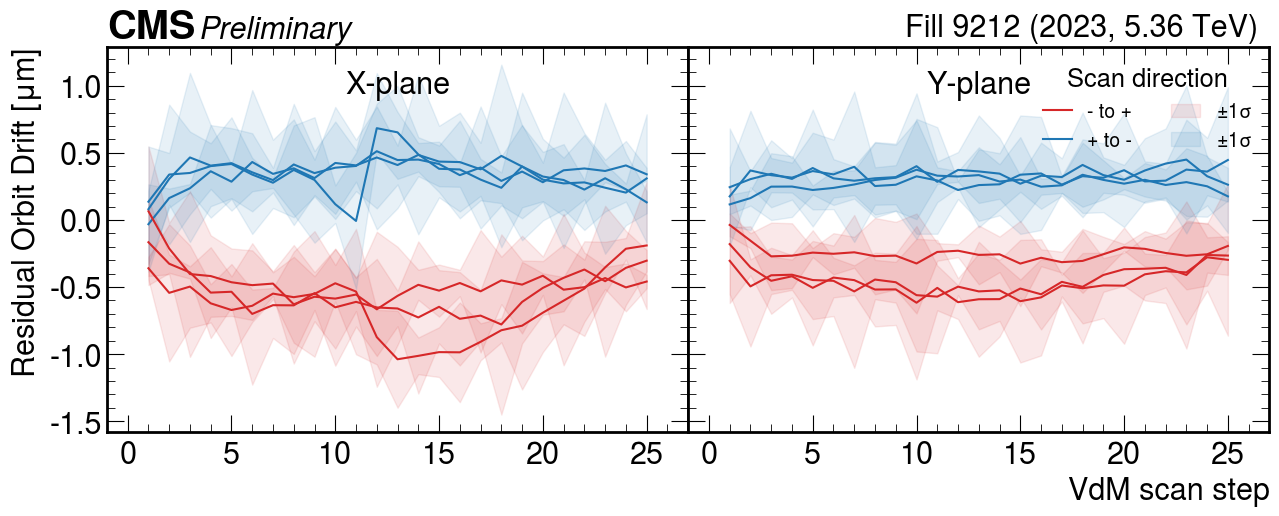

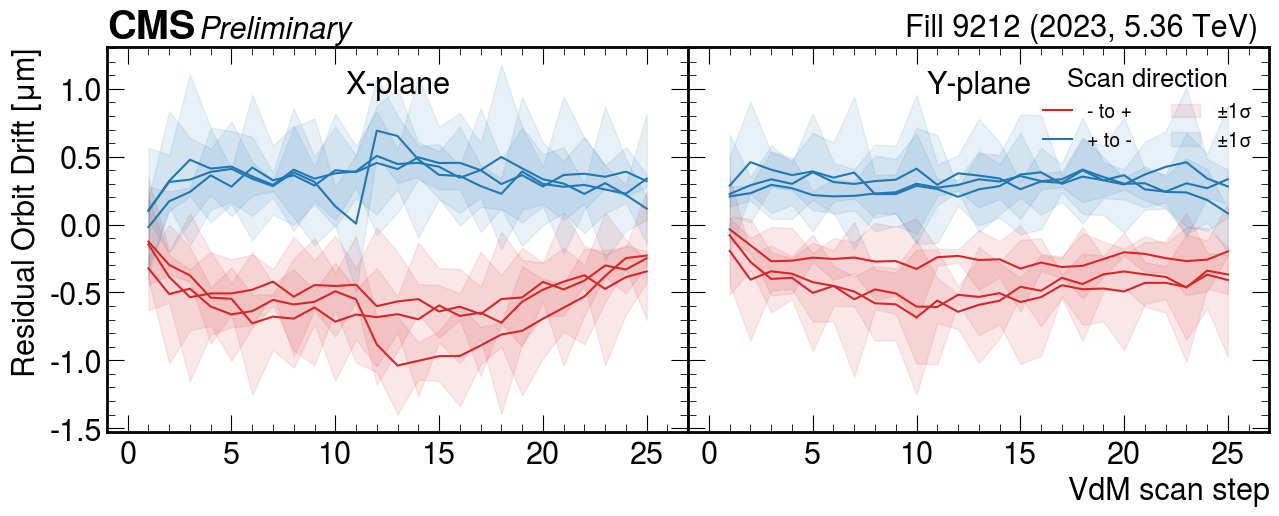

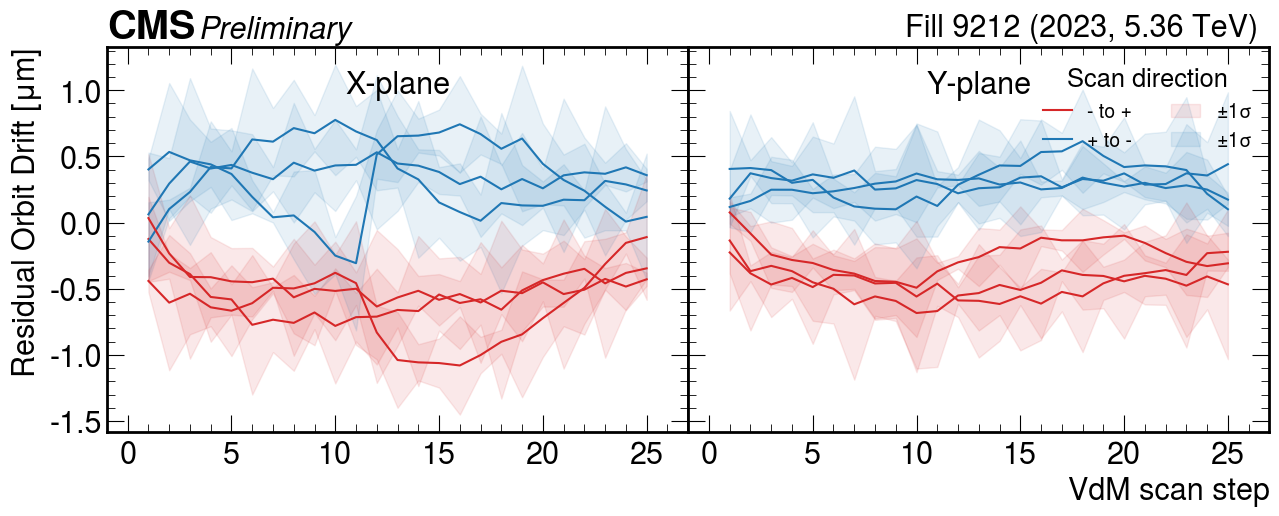

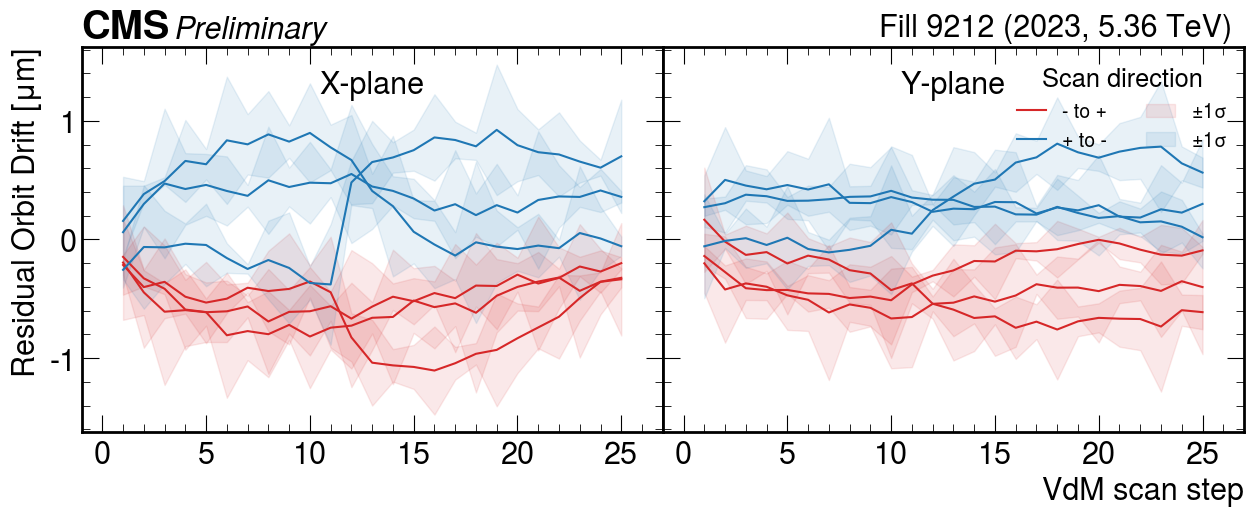

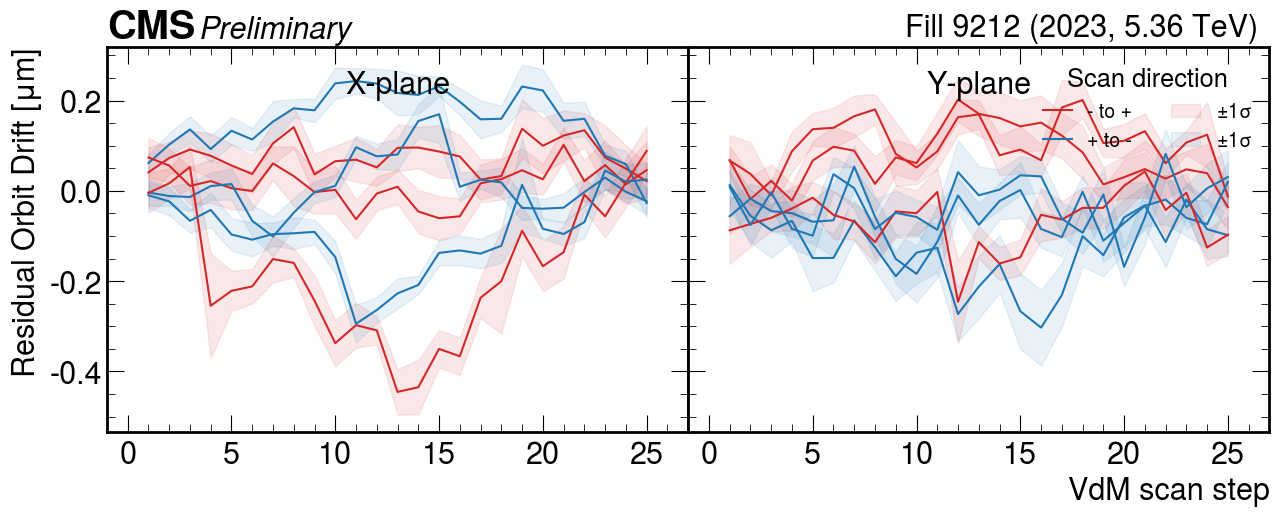

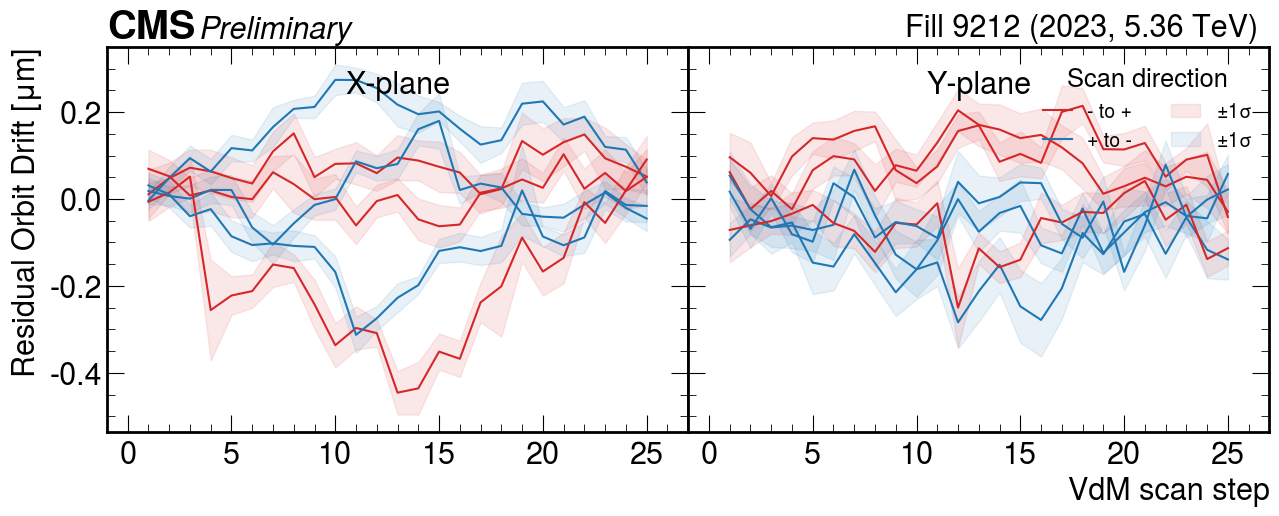

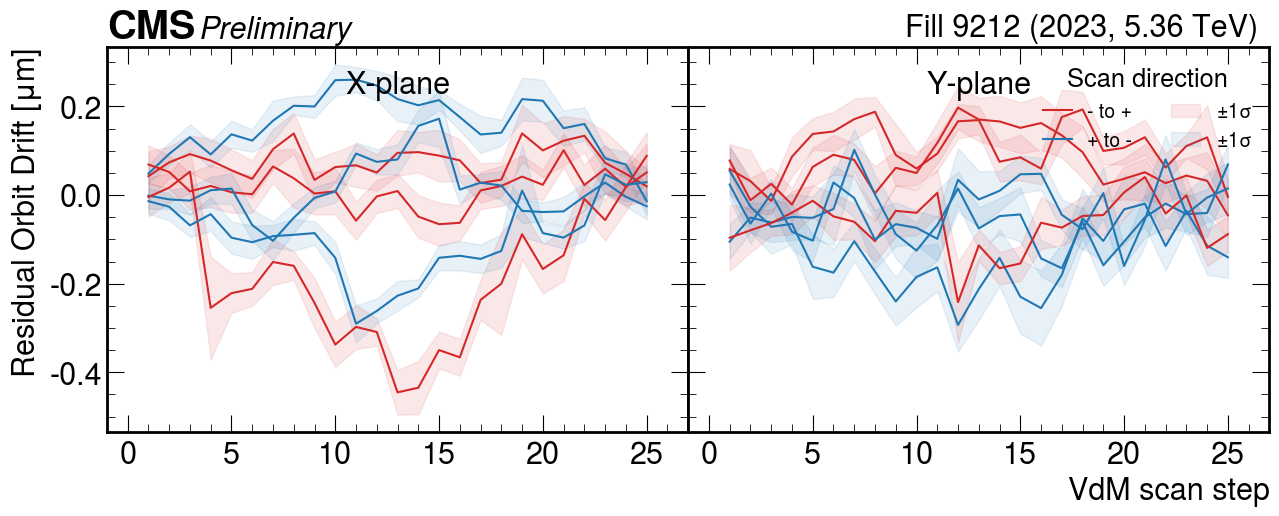

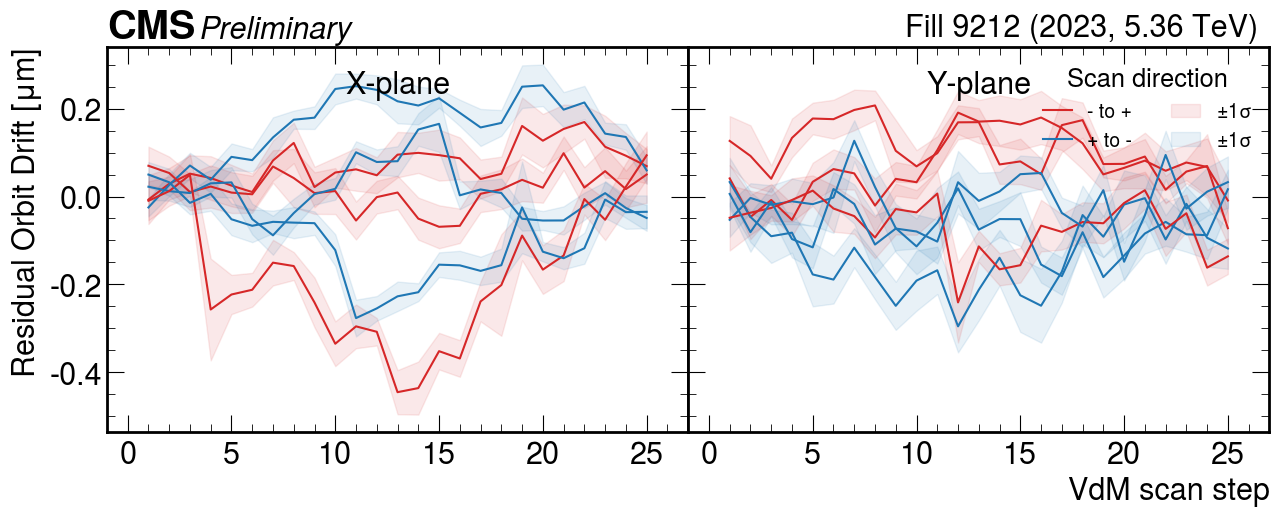

In [36]:
#vs step in plane separation residual plots only for vdM scans for all fitting methods
for bpm in bpms :
    for method in fit_results :
        fig, axs = plt.subplots(1,2,figsize=(15,5), sharex=True, sharey=True)
        
        hep.cms.text(cmstext, ax=axs[0], loc=0, fontsize=22)
        
        #axs[0].set_ylim(-2.5,4.1)
        axs[0].set_title('X-plane', y=0.97, pad=-25, size=22)
        axs[1].set_title('Y-plane', y=0.97, pad=-25, size=22)
        fig.subplots_adjust(wspace=0, hspace=0)
        axs[1].tick_params('y', labelleft=False)
        axs[1].set_xlabel('VdM scan step', fontsize=22)
        axs[1].text(0.98, 1.01, filltext,
                                horizontalalignment='right',
                                verticalalignment='bottom',
                                transform=axs[1].transAxes,
                                fontname='sans-serif',
                                color="k",
                                fontsize=22)
        axs[0].set_ylabel("Residual Orbit Drift [$\mu m$]", fontsize=22)
        axs[1].plot([],[],'-',color=colors[3],label='- to +')
        axs[1].plot([],[],'-',color=colors[0],label = '+ to -')
        axs[1].fill_between([],[],[],color=colors[3],alpha=0.1,label= '$\pm 1 \sigma$')
        axs[1].fill_between([],[],[],color=colors[0],alpha=0.1,label = '$\pm 1 \sigma$')
        
        for scan in data_array :
            if data_array[scan]['subscan'] == 'vdM' : #or data_array[scan]['subscan'] == 'im1' or data_array[scan]['subscan'] == 'im2' :
                x1residuals = []
                y1residuals = []
                x2residuals = []
                y2residuals = []
                x1err = []
                y1err = []
                x2err = []
                y2err = []
                if data_array[scan]['axis'] == 1 and (data_array[scan]['beam'] == 1 or data_array[scan]['beam'] == 0):
                    x1residuals.extend(data_array[scan][method + '_' + bpm + 'X1_res_noconst']*1000)
                    x1err.extend(np.array(data_array[scan][bpm + 'errX1'])*1000)
                if data_array[scan]['axis'] == 1 and (data_array[scan]['beam'] == 2 or data_array[scan]['beam'] == 0):
                    x2residuals.extend(data_array[scan][method + '_' + bpm + 'X2_res_noconst']*1000)
                    x2err.extend(np.array(data_array[scan][bpm + 'errX2'])*1000)
                if data_array[scan]['axis'] == 2 and (data_array[scan]['beam'] == 1 or data_array[scan]['beam'] == 0):
                    y1residuals.extend(data_array[scan][method + '_' + bpm + 'Y1_res_noconst']*1000)
                    y1err.extend(np.array(data_array[scan][bpm + 'errY1'])*1000)
                if data_array[scan]['axis'] == 2 and (data_array[scan]['beam'] == 2 or data_array[scan]['beam'] == 0):
                    y2residuals.extend(data_array[scan][method + '_' + bpm + 'Y2_res_noconst']*1000)
                    y2err.extend(np.array(data_array[scan][bpm + 'errY2'])*1000)
        
                stepsx1 = [i+1 for i in range(0,len(x1residuals))]
                stepsy1 = [i+1 for i in range(0,len(y1residuals))]
                stepsx2 = [i+1 for i in range(0,len(x2residuals))]
                stepsy2 = [i+1 for i in range(0,len(y2residuals))]
               
                if(data_array[scan]['subscan'] == 'im1' or data_array[scan]['subscan'] == 'im2') :
                    axs[0].plot(stepsx1,x1residuals,'-',color=colors[3])
                    axs[0].plot(stepsx2,x2residuals,'-',color=colors[3])
                    axs[1].plot(stepsy1,y1residuals,'-',color=colors[3])
                    axs[1].plot(stepsy2,y2residuals,'-',color=colors[3])
                else :
                    axs[0].plot(stepsx1,x1residuals,'-',color=colors[3])
                    axs[0].fill_between(stepsx1,np.array(x1residuals)-np.array(x1err),np.array(x1residuals)+np.array(x1err),color=colors[3],alpha=0.1)
                    axs[0].plot(stepsx2,x2residuals,'-',color=colors[0])
                    axs[0].fill_between(stepsx2,np.array(x2residuals)-np.array(x2err),np.array(x2residuals)+np.array(x2err),color=colors[0],alpha=0.1)
                    axs[1].plot(stepsy1,y1residuals,'-',color=colors[3])
                    axs[1].fill_between(stepsy1,np.array(y1residuals)-np.array(y1err),np.array(y1residuals)+np.array(y1err),color=colors[3],alpha=0.1)
                    axs[1].plot(stepsy2,y2residuals,'-',color=colors[0])
                    axs[1].fill_between(stepsy2,np.array(y2residuals)-np.array(y2err),np.array(y2residuals)+np.array(y2err),color=colors[0],alpha=0.1)
               
                #axs[1].legend(bbox_to_anchor=(1.01, 0.5), ncol=1, loc="center left", prop={'size': 20})
                legend = axs[1].legend(ncol=2, bbox_to_anchor=(0.79, 0.84), loc="center", fontsize=14)
                legend.set_title('Scan direction',prop={'size':'smaller'})
                plt.xlim(-1,27)
                if fill == '6868' : plt.ylim(-4.3,7.8)
                if fill == '9626' : plt.ylim(-2.5,4.2)
        
        fig.savefig(PATH + "figures_fill" + fill + "/" + "resod_vs_step_vdm_" + bpm + "_" + method + "_best_fill" + fill + '.pdf', bbox_inches='tight')
        fig.savefig(PATH + "figures_fill" + fill + "/" + "resod_vs_step_vdm_" + bpm + "_" + method + "_best_fill" + fill + '.png', bbox_inches='tight')